In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
%cd /content
!rm -rf PIDNet  # Ensures a clean start
!git clone https://github.com/XuJiacong/PIDNet.git
%cd /content/PIDNet

/content
Cloning into 'PIDNet'...
remote: Enumerating objects: 398, done.
remote: Counting objects: 100% (201/201), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 398 (delta 139), reused 128 (delta 128), pack-reused 197 (from 2)
Receiving objects: 100% (398/398), 212.80 MiB | 47.33 MiB/s, done.
Resolving deltas: 100% (192/192), done.
/content/PIDNet


In [ ]:
!cp -f /content/drive/MyDrive/CSS/model/pidnet_cl.py /content/PIDNet/models/pidnet_cl.py

## PIDNet-S

15 to 16 classes (ver1)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torch.cuda.amp import GradScaler, autocast
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
import numpy as np
import os, glob
from tqdm import tqdm
from models.pidnet_cl import PIDNetCL

# ==========================================
# 1. SETUP: RGB DATASET (Official Config)
# ==========================================
DATA_ROOT = "/content/drive/MyDrive/CSS/PIDNet/data/cityscapes"
NEW_CLASS_ID = 28
img_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # RGB Stats
])

class CityscapesCL(Dataset):
    def __init__(self, root, split="train"):
        self.img_dir = os.path.join(root, "leftImg8bit", split)
        self.gt_dir = os.path.join(root, "gtFine", split)
        self.items = []
        # Find images
        if os.path.exists(self.img_dir):
            for city in sorted(os.listdir(self.img_dir)):
                imgs = sorted(glob.glob(os.path.join(self.img_dir, city, "*_leftImg8bit.png")))
                for ip in imgs:
                    gp = os.path.join(self.gt_dir, city, os.path.basename(ip).replace("_leftImg8bit.png", "_gtFine_labelIds.png"))
                    if os.path.exists(gp): self.items.append((ip, gp))

    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        ip, gp = self.items[idx]
        # RGB Loading (Matches Official PIDNet training)
        img = img_tf(Image.open(ip).convert("RGB"))
        lbl = np.array(Image.open(gp), dtype=np.uint8)

        # Binary Target for Training (Bus vs Rest)
        tgt = np.full_like(lbl, 255)
        valid_bg = [7,8,11,12,13,17,19,20,21,22,23,24,25,26,27]
        for c in valid_bg: tgt[lbl == c] = 0
        tgt[lbl == NEW_CLASS_ID] = 1
        return img, torch.from_numpy(tgt).long(), lbl # Return raw label for eval

# ==========================================
# 2. MODEL: LOAD & FREEZE
# ==========================================
print("=> Initializing Model & Loading Base Weights...")
model = PIDNetCL(m=2, n=3, num_classes=15, planes=32, ppm_planes=96, head_planes=128, augment=True)
ckpt = torch.load("/content/drive/MyDrive/CSS/PIDNet/output/cityscapes/pidnet_s_custom_15/best.pt", map_location="cpu")
state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt
state_dict = {k.replace('module.', '').replace('model.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict, strict=False)

# Freeze Old, Thaw New
for name, p in model.named_parameters():
    p.requires_grad = any(t in name for t in ["layer3_d_new","layer4_d_new","diff3_new","diff4_new","seghead_new"])
model.cuda()
model.train()

# ==========================================
# 3. TRAIN: SUBSET ONLY
# ==========================================
print("=> Preparing Training Data...")
train_set = CityscapesCL(DATA_ROOT, "train")
bus_indices = [i for i, (_, gp) in enumerate(train_set.items) if (np.array(Image.open(gp)) == NEW_CLASS_ID).any()]
train_loader = DataLoader(Subset(train_set, bus_indices), batch_size=6, shuffle=True, num_workers=2, pin_memory=True)

print(f"=> Retraining New Branch (RGB) on {len(bus_indices)} images...")
optim = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
crit = nn.CrossEntropyLoss(ignore_index=255)
scaler = GradScaler(enabled=True)

for epoch in range(20): # Fast retraining (5 epochs of the subset is enough to recover)
    for i, (img, tgt, _) in enumerate(train_loader):
        img, tgt = img.cuda(), tgt.cuda()
        with autocast(enabled=True):
            out = model.forward_with_new(img)
            loss = crit(out["logits_new_2ch"], tgt)
        optim.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()
    print(f"   Epoch {epoch+1} Loss: {loss.item():.4f}")

# ==========================================
# 4. EVALUATE: DUAL MODE (LEGACY vs HONEST)
# ==========================================
print("\n=> Running Dual-Mode Evaluation (Validation Set)...")
val_set = CityscapesCL(DATA_ROOT, "val")
val_loader = DataLoader(val_set, batch_size=4, shuffle=False, num_workers=2)

@torch.no_grad()
def fuse(o15, onew, tau=0.55):
    p_new = torch.softmax(onew, dim=1)[:, 1:2]
    return torch.where(p_new >= tau, torch.tensor(15).to(p_new.device), o15.argmax(1, keepdim=True)).squeeze(1)

model.eval()
# Confusion Matrices
cm_legacy = torch.zeros((15, 15), dtype=torch.long).cuda() # Original 15 classes
cm_honest = torch.zeros((16, 16), dtype=torch.long).cuda() # All 16 classes

id_map_15 = {7:0,8:1,11:2,12:3,13:4,17:5,19:6,20:7,21:8,22:9,23:10,24:11,25:12,26:13,27:14}

for img, _, raw_lbl in tqdm(val_loader):
    img = img.cuda()
    raw_lbl = raw_lbl.long().cuda()

    # 1. Forward & Up
    out = model.forward_with_new(img)
    l15 = F.interpolate(out["logits_15"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)
    lnew = F.interpolate(out["logits_new_2ch"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)
    pred = fuse(l15, lnew, tau=0.55) # Use 0.55 or adjust higher if Truck drops too much

    # 2. Prepare Targets (16 Class)
    tgt_16 = torch.full_like(raw_lbl, 255)
    for k, v in id_map_15.items(): tgt_16[raw_lbl == k] = v
    tgt_16[raw_lbl == NEW_CLASS_ID] = 15

    # 3. Prepare Targets (15 Class Legacy - Ignore Bus)
    tgt_15 = tgt_16.clone()
    tgt_15[tgt_15 == 15] = 255 # IGNORE BUS PIXELS (Matches Base Model Evaluation)

    # 4. Update Matrices
    mask16 = tgt_16 != 255
    if mask16.any():
        cm_honest += torch.bincount(tgt_16[mask16]*16 + pred[mask16], minlength=256).view(16,16)

    mask15 = tgt_15 != 255
    if mask15.any():
        # Map predictions of "15" (Bus) back to something else or just mask them?
        # In legacy mode, if we predict "Bus", it's technically a "Non-15-class" prediction.
        # But usually we just calculate IoU on 0-14.
        p15_view = pred[mask15]
        # Only count if prediction is 0-14 (Valid Legacy)
        valid_p = p15_view < 15
        if valid_p.any():
            cm_legacy += torch.bincount(tgt_15[mask15][valid_p]*15 + p15_view[valid_p], minlength=225).view(15,15)

# Calculate Scores
iou_leg = torch.diag(cm_legacy) / (cm_legacy.sum(1) + cm_legacy.sum(0) - torch.diag(cm_legacy) + 1e-6)
iou_hon = torch.diag(cm_honest) / (cm_honest.sum(1) + cm_honest.sum(0) - torch.diag(cm_honest) + 1e-6)

print(f"\nLegacy mIoU (15 Class): {iou_leg.mean().item()*100:.2f}%  -- Should be around 79%")
print(f"Honest mIoU (16 Class): {iou_hon.mean().item()*100:.2f}%  -- Real System Performance")
print(f"Truck (Legacy): {iou_leg[14].item()*100:.2f}% | Bus (Honest): {iou_hon[15].item()*100:.2f}%")

=> Initializing Model & Loading Base Weights...
=> Preparing Training Data...
=> Retraining New Branch (RGB) on 274 images...


/tmp/ipython-input-3045314970.py:77: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)
/tmp/ipython-input-3045314970.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


   Epoch 1 Loss: 0.1559
   Epoch 2 Loss: 0.0300
   Epoch 3 Loss: 0.0260
   Epoch 4 Loss: 0.0107
   Epoch 5 Loss: 0.0203
   Epoch 6 Loss: 0.0281
   Epoch 7 Loss: 0.0180
   Epoch 8 Loss: 0.0289
   Epoch 9 Loss: 0.0088
   Epoch 10 Loss: 0.0115
   Epoch 11 Loss: 0.0122
   Epoch 12 Loss: 0.0140
   Epoch 13 Loss: 0.0174
   Epoch 14 Loss: 0.0074
   Epoch 15 Loss: 0.0171
   Epoch 16 Loss: 0.0116
   Epoch 17 Loss: 0.0173
   Epoch 18 Loss: 0.0101
   Epoch 19 Loss: 0.0061
   Epoch 20 Loss: 0.0098

=> Running Dual-Mode Evaluation (Validation Set)...


100%|██████████| 125/125 [00:45<00:00,  2.72it/s]


Legacy mIoU (15 Class): 77.24%  -- Should be around 79%
Honest mIoU (16 Class): 72.71%  -- Real System Performance
Truck (Legacy): 76.28% | Bus (Honest): 36.34%


=> Loading specific image: frankfurt_000001_067295...


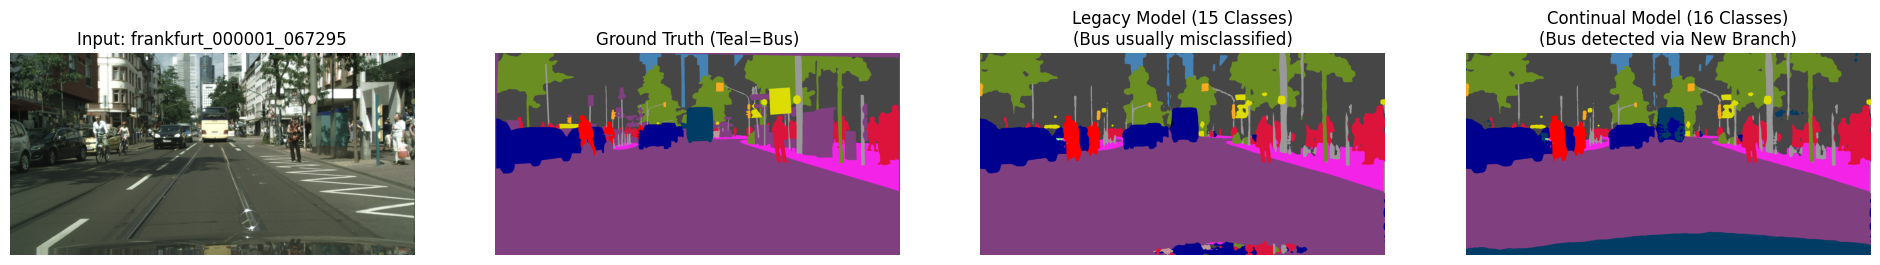

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import os
from PIL import Image
import torchvision.transforms as T
import torch.nn.functional as F

# ==========================================
# 1. SETUP & CONFIG
# ==========================================
DATA_ROOT = "/content/drive/MyDrive/CSS/PIDNet/data/cityscapes"

# The specific file ID you requested
CITY = "frankfurt"
FILE_ID = "frankfurt_000001_067295"

# Construct full paths based on Cityscapes structure
input_path = os.path.join(DATA_ROOT, "leftImg8bit", "val", CITY, f"{FILE_ID}_leftImg8bit.png")
gt_path = os.path.join(DATA_ROOT, "gtFine", "val", CITY, f"{FILE_ID}_gtFine_labelIds.png")

# Define the Palette (Same as before)
CITYSCAPES_PALETTE = np.array([
    [128, 64, 128],  # 0: road
    [244, 35, 232],  # 1: sidewalk
    [70, 70, 70],    # 2: building
    [102, 102, 156], # 3: wall
    [190, 153, 153], # 4: fence
    [153, 153, 153], # 5: pole
    [250, 170, 30],  # 6: traffic light
    [220, 220, 0],   # 7: traffic sign
    [107, 142, 35],  # 8: vegetation
    [152, 251, 152], # 9: terrain
    [70, 130, 180],  # 10: sky
    [220, 20, 60],   # 11: person
    [255, 0, 0],     # 12: rider
    [0, 0, 142],     # 13: car
    [0, 0, 70],      # 14: truck
    [0, 60, 100],    # 15: BUS (New Class)
    [0, 80, 100],    # 16: train
    [0, 0, 230],     # 17: motorcycle
    [119, 11, 32]    # 18: bicycle
], dtype=np.uint8)

def colorize(mask):
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for label_id in range(len(CITYSCAPES_PALETTE)):
        color_mask[mask == label_id] = CITYSCAPES_PALETTE[label_id]
    return color_mask

# ==========================================
# 2. LOAD SPECIFIC IMAGE
# ==========================================
if not os.path.exists(input_path):
    print(f"Error: Image not found at {input_path}")
else:
    print(f"=> Loading specific image: {FILE_ID}...")

    # Load and Preprocess
    raw_img = Image.open(input_path).convert("RGB")
    raw_lbl = np.array(Image.open(gt_path), dtype=np.uint8)

    img_tensor = img_tf(raw_img).unsqueeze(0).cuda() # Add batch dim

    # ==========================================
    # 3. RUN INFERENCE (Legacy vs New)
    # ==========================================
    model.eval()
    with torch.no_grad():
        out = model.forward_with_new(img_tensor)

        # A. Old Prediction (15 Classes)
        l15 = F.interpolate(out["logits_15"], raw_lbl.shape, mode='bilinear', align_corners=True)
        pred_old = l15.argmax(1).squeeze(0).cpu().numpy()

        # B. New Prediction (16 Classes - Fused)
        lnew = F.interpolate(out["logits_new_2ch"], raw_lbl.shape, mode='bilinear', align_corners=True)
        pred_fused = fuse(l15, lnew, tau=0.55).squeeze(0).cpu().numpy()

    # ==========================================
    # 4. VISUALIZE
    # ==========================================
    # Prepare Display Image
    vis_img = np.array(raw_img)

    # Prepare GT (Map Bus 28 -> 15 for visualization)
    # Re-using the id_map_15 from your previous code block
    gt_vis_map = np.zeros_like(raw_lbl)
    # NOTE: Ensure id_map_15 is defined. If not, uncomment the line below:
    id_map_15 = {7:0,8:1,11:2,12:3,13:4,17:5,19:6,20:7,21:8,22:9,23:10,24:11,25:12,26:13,27:14}

    for k, v in id_map_15.items(): gt_vis_map[raw_lbl == k] = v
    gt_vis_map[raw_lbl == NEW_CLASS_ID] = 15 # Bus

    # Colorize Masks
    vis_gt = colorize(gt_vis_map)
    vis_old = colorize(pred_old)
    vis_new = colorize(pred_fused)

    # Plot
    fig, axs = plt.subplots(1, 4, figsize=(24, 6))

    axs[0].imshow(vis_img)
    axs[0].set_title(f"Input: {FILE_ID}")
    axs[0].axis('off')

    axs[1].imshow(vis_gt)
    axs[1].set_title("Ground Truth (Teal=Bus)")
    axs[1].axis('off')

    axs[2].imshow(vis_old)
    axs[2].set_title("Legacy Model (15 Classes)\n(Bus usually misclassified)")
    axs[2].axis('off')

    axs[3].imshow(vis_new)
    axs[3].set_title("Continual Model (16 Classes)\n(Bus detected via New Branch)")
    axs[3].axis('off')

    plt.show()

In [ ]:
# Save the model from Step 1 (15 Base + 1 New Branch)
torch.save(model.state_dict(), "step1_result.pt")
print("=> Step 1 model saved as 'step1_result.pt'")

=> Step 1 model saved as 'step1_result.pt'


16-17

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torch.cuda.amp import GradScaler, autocast
import numpy as np
import os
import glob
from PIL import Image
from tqdm import tqdm
import torchvision.transforms as T
from models.pidnet_cl import PIDNetCL
from models.model_utils import segmenthead

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_ROOT = "/content/drive/MyDrive/CSS/PIDNet/data/cityscapes"
# Point this to your Step 1 result
PREV_CKPT_PATH = "/content/PIDNet/step1_result.pt"
SAVE_PATH = "step2_result_17classes.pt"

# IDs
CLASS_ID_BUS = 28
CLASS_ID_TRAIN = 31

img_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 2. DATASET: 3-Way Target (BG, Bus, Train)
# ==========================================
class CityscapesCL_Step2(torch.utils.data.Dataset):
    def __init__(self, root, split="train"):
        self.img_dir = os.path.join(root, "leftImg8bit", split)
        self.gt_dir = os.path.join(root, "gtFine", split)
        self.items = []
        if os.path.exists(self.img_dir):
            for city in sorted(os.listdir(self.img_dir)):
                imgs = sorted(glob.glob(os.path.join(self.img_dir, city, "*_leftImg8bit.png")))
                for ip in imgs:
                    gp = os.path.join(self.gt_dir, city, os.path.basename(ip).replace("_leftImg8bit.png", "_gtFine_labelIds.png"))
                    if os.path.exists(gp): self.items.append((ip, gp))

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        ip, gp = self.items[idx]
        img = img_tf(Image.open(ip).convert("RGB"))
        lbl = np.array(Image.open(gp), dtype=np.uint8)

        # 0 = Background (Base classes)
        # 1 = Bus (Keep Memory)
        # 2 = Train (New Learn)
        tgt = np.full_like(lbl, 255)

        # Original 15 context classes are Background for this branch
        valid_bg = [7,8,11,12,13,17,19,20,21,22,23,24,25,26,27]
        for c in valid_bg: tgt[lbl == c] = 0

        tgt[lbl == CLASS_ID_BUS] = 1   # Bus is Class 1 in this branch
        tgt[lbl == CLASS_ID_TRAIN] = 2 # Train is Class 2 in this branch

        return img, torch.from_numpy(tgt).long(), lbl

# ==========================================
# 3. MODEL SETUP: EXPAND THE BRANCH
# ==========================================
print("=> Loading Step 1 Model...")
model = PIDNetCL(m=2, n=3, num_classes=15, planes=32, ppm_planes=96, head_planes=128, augment=True)
ckpt = torch.load(PREV_CKPT_PATH, map_location="cpu")
state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt
state_dict = {k.replace('module.', '').replace('model.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict, strict=False)

print("=> Expanding New Branch Head (2 -> 3 channels)...")

# 1. Access the specific final layer (conv2) inside the head
old_layer = model.seghead_new.conv2

# 2. Get old weights
old_w = old_layer.weight.data # [2, 128, 1, 1]
old_b = old_layer.bias.data   # [2]

# 3. Create new layer with 3 outputs
# We use old_layer.in_channels (128) to ensure it matches the head_planes
new_layer = nn.Conv2d(old_layer.in_channels, 3, kernel_size=1, padding=0, bias=True)

# 4. Copy Weights (Preserve Bus Memory)
# Copy BG (idx 0) and Bus (idx 1)
new_layer.weight.data[:2] = old_w
new_layer.bias.data[:2] = old_b
# Train (idx 2) is randomly initialized

print(f"   Head Expanded: {old_w.shape} -> {new_layer.weight.data.shape}")

# 5. Swap the layer
model.seghead_new.conv2 = new_layer

model.cuda()

# ==========================================
# 4. TRAIN (Protected BN)
# ==========================================
model.eval()
trainable_modules = ["layer3_d_new", "layer4_d_new", "diff3_new", "diff4_new", "seghead_new"]

for name, m in model.named_modules():
    if any(t in name for t in trainable_modules):
        m.train()
        for p in m.parameters():
            p.requires_grad = True
    else:
        for p in m.parameters():
            p.requires_grad = False

print(f"\n=> Retraining for Bus (Maintain) + Train (Learn)...")
train_set = CityscapesCL_Step2(DATA_ROOT, "train")
# Train on images that have EITHER Bus OR Train
active_indices = [i for i, (_, gp) in enumerate(train_set.items) if
                  (np.array(Image.open(gp)) == CLASS_ID_BUS).any() or
                  (np.array(Image.open(gp)) == CLASS_ID_TRAIN).any()]

train_loader = DataLoader(Subset(train_set, active_indices), batch_size=6, shuffle=True, num_workers=2, pin_memory=True)

optim = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
crit = nn.CrossEntropyLoss(ignore_index=255)
scaler = GradScaler(enabled=True)

for epoch in range(20):
    epoch_loss = 0
    for i, (img, tgt, _) in enumerate(train_loader):
        img, tgt = img.cuda(), tgt.cuda()
        with autocast(enabled=True):
            # Returns 3 channels now
            out = model.forward_with_new(img)
            # We access 'logits_new_2ch' because that's the key name in pidnet_cl.py
            loss = crit(out["logits_new_2ch"], tgt)

        optim.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()
        epoch_loss += loss.item()
    print(f"   Epoch {epoch+1} Loss: {epoch_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), SAVE_PATH)

# ==========================================
# 5. EVALUATION (3-WAY FUSION)
# ==========================================
print("\n=> Running Evaluation...")
val_set_eval = CityscapesCL_Step2(DATA_ROOT, "val")
val_loader = DataLoader(val_set_eval, batch_size=4, shuffle=False, num_workers=2)

ID_MAP = {
    7:0, 8:1, 11:2, 12:3, 13:4, 17:5, 19:6, 20:7,
    21:8, 22:9, 23:10, 24:11, 25:12, 26:13, 27:14,
    CLASS_ID_BUS: 15,
    CLASS_ID_TRAIN: 16
}

@torch.no_grad()
def fuse_3way(logits_base, logits_new, tau=0.55):
    # logits_base: [B, 15, H, W]
    # logits_new:  [B, 3, H, W] -> (BG, Bus, Train)

    probs_new = torch.softmax(logits_new, dim=1)

    # Check max probability among the "Active" classes (Bus & Train)
    # slice [:, 1:] gets columns 1 (Bus) and 2 (Train)
    max_new_val, max_new_idx = torch.max(probs_new[:, 1:], dim=1)

    pred_base = logits_base.argmax(1)

    # if max_new_idx is 0 -> it refers to Bus (Class 15)
    # if max_new_idx is 1 -> it refers to Train (Class 16)
    pred_new_mapped = max_new_idx + 15

    return torch.where(max_new_val >= tau, pred_new_mapped, pred_base)

model.eval()
cm = torch.zeros((17, 17), dtype=torch.long).cuda()

for img, _, raw_lbl in tqdm(val_loader):
    img = img.cuda()
    raw_lbl = raw_lbl.long().cuda()

    out = model.forward_with_new(img)
    l_base = F.interpolate(out["logits_15"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)
    l_new = F.interpolate(out["logits_new_2ch"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)

    pred = fuse_3way(l_base, l_new)

    tgt = torch.full_like(raw_lbl, 255)
    for k, v in ID_MAP.items():
        tgt[raw_lbl == k] = v

    mask = tgt != 255
    if mask.any():
        cm += torch.bincount(tgt[mask]*17 + pred[mask], minlength=289).view(17,17)

iou_per_class = torch.diag(cm) / (cm.sum(1) + cm.sum(0) - torch.diag(cm) + 1e-6)

print("\n" + "="*40)
print(f"Legacy (15 Classes) mIoU:   {iou_per_class[0:15].mean().item()*100:.2f}%")
print(f"Step 1 (16 Classes) mIoU:   {iou_per_class[0:16].mean().item()*100:.2f}% (Includes Bus)")
print(f"Actual (17 Classes) mIoU:   {iou_per_class[0:17].mean().item()*100:.2f}% (Includes Train)")
print("="*40)
print(f"Bus IoU:   {iou_per_class[15].item()*100:.2f}%")
print(f"Train IoU: {iou_per_class[16].item()*100:.2f}%")

=> Loading Step 1 Model...
=> Expanding New Branch Head (2 -> 3 channels)...
   Head Expanded: torch.Size([2, 128, 1, 1]) -> torch.Size([3, 128, 1, 1])

=> Retraining for Bus (Maintain) + Train (Learn)...


/tmp/ipython-input-263076500.py:130: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)
/tmp/ipython-input-263076500.py:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


   Epoch 1 Loss: 0.0635
   Epoch 2 Loss: 0.0459
   Epoch 3 Loss: 0.0368
   Epoch 4 Loss: 0.0331
   Epoch 5 Loss: 0.0288
   Epoch 6 Loss: 0.0266
   Epoch 7 Loss: 0.0234
   Epoch 8 Loss: 0.0204
   Epoch 9 Loss: 0.0196
   Epoch 10 Loss: 0.0189
   Epoch 11 Loss: 0.0169
   Epoch 12 Loss: 0.0146
   Epoch 13 Loss: 0.0244
   Epoch 14 Loss: 0.0216
   Epoch 15 Loss: 0.0155
   Epoch 16 Loss: 0.0117
   Epoch 17 Loss: 0.0106
   Epoch 18 Loss: 0.0097
   Epoch 19 Loss: 0.0096
   Epoch 20 Loss: 0.0081

=> Running Evaluation...


100%|██████████| 125/125 [00:42<00:00,  2.91it/s]


Legacy (15 Classes) mIoU:   75.32%
Step 1 (16 Classes) mIoU:   73.23% (Includes Bus)
Actual (17 Classes) mIoU:   69.94% (Includes Train)
Bus IoU:   41.74%
Train IoU: 17.36%


17-18

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torch.cuda.amp import GradScaler, autocast
import numpy as np
import os
import glob
from PIL import Image
from tqdm import tqdm
import torchvision.transforms as T
from models.pidnet_cl import PIDNetCL
from models.model_utils import segmenthead

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_ROOT = "/content/drive/MyDrive/CSS/PIDNet/data/cityscapes"

# IMPORTANT: Point this to the result of STEP 2
PREV_CKPT_PATH = "step2_result_17classes.pt"
SAVE_PATH = "step3_result_18classes.pt"

# IDs
CLASS_ID_BUS = 28
CLASS_ID_TRAIN = 31
CLASS_ID_MOTOR = 32 # The New Class (18th)

img_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 2. DATASET: 4-Way Target (BG, Bus, Train, Motor)
# ==========================================
class CityscapesCL_Step3(torch.utils.data.Dataset):
    def __init__(self, root, split="train"):
        self.img_dir = os.path.join(root, "leftImg8bit", split)
        self.gt_dir = os.path.join(root, "gtFine", split)
        self.items = []
        if os.path.exists(self.img_dir):
            for city in sorted(os.listdir(self.img_dir)):
                imgs = sorted(glob.glob(os.path.join(self.img_dir, city, "*_leftImg8bit.png")))
                for ip in imgs:
                    gp = os.path.join(self.gt_dir, city, os.path.basename(ip).replace("_leftImg8bit.png", "_gtFine_labelIds.png"))
                    if os.path.exists(gp): self.items.append((ip, gp))

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        ip, gp = self.items[idx]
        img = img_tf(Image.open(ip).convert("RGB"))
        lbl = np.array(Image.open(gp), dtype=np.uint8)

        # 0 = Background (Base classes)
        # 1 = Bus
        # 2 = Train
        # 3 = Motorcycle (New)
        tgt = np.full_like(lbl, 255)

        # Original 15 context classes are Background
        valid_bg = [7,8,11,12,13,17,19,20,21,22,23,24,25,26,27]
        for c in valid_bg: tgt[lbl == c] = 0

        tgt[lbl == CLASS_ID_BUS] = 1
        tgt[lbl == CLASS_ID_TRAIN] = 2
        tgt[lbl == CLASS_ID_MOTOR] = 3 # New Target

        return img, torch.from_numpy(tgt).long(), lbl

# ==========================================
# 3. MODEL SETUP: EXPAND TO 4 CHANNELS
# ==========================================
print("=> Loading Step 2 Model...")
# Base is always 15
model = PIDNetCL(m=2, n=3, num_classes=15, planes=32, ppm_planes=96, head_planes=128, augment=True)

# Use the specific logic for Step 3 expansion (needs to handle the 3-channel head from step 2)
# But wait! PIDNetCL init creates a 2-channel head by default.
# We need to manually expand it to 3 channels FIRST so we can load the Step 2 weights.
model.seghead_new = segmenthead(32 * 2, 128, 3) # Pre-expand to match Step 2 checkpoint

ckpt = torch.load(PREV_CKPT_PATH, map_location="cpu")
state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt
state_dict = {k.replace('module.', '').replace('model.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict, strict=True) # strict=True should work now

print("=> Expanding Head (3 -> 4 channels)...")
old_layer = model.seghead_new.conv2
old_w = old_layer.weight.data # [3, 128, 1, 1]
old_b = old_layer.bias.data   # [3]

# Create new layer with 4 outputs
new_layer = nn.Conv2d(old_layer.in_channels, 4, kernel_size=1, padding=0, bias=True)

# Copy Weights (Preserve BG, Bus, Train)
# Copy indices 0, 1, 2
new_layer.weight.data[:3] = old_w
new_layer.bias.data[:3] = old_b
# Index 3 (Motor) is random

print(f"   Head Expanded: {old_w.shape} -> {new_layer.weight.data.shape}")
model.seghead_new.conv2 = new_layer
model.cuda()

# ==========================================
# 4. TRAIN (Protected BN)
# ==========================================
model.eval()
trainable_modules = ["layer3_d_new", "layer4_d_new", "diff3_new", "diff4_new", "seghead_new"]
for name, m in model.named_modules():
    if any(t in name for t in trainable_modules):
        m.train()
        for p in m.parameters():
            p.requires_grad = True
    else:
        for p in m.parameters():
            p.requires_grad = False

print(f"\n=> Retraining for Bus+Train+Motor...")
train_set = CityscapesCL_Step3(DATA_ROOT, "train")
# Train on images containing ANY of the special classes
active_indices = [i for i, (_, gp) in enumerate(train_set.items) if
                  (np.array(Image.open(gp)) == CLASS_ID_BUS).any() or
                  (np.array(Image.open(gp)) == CLASS_ID_TRAIN).any() or
                  (np.array(Image.open(gp)) == CLASS_ID_MOTOR).any()]

train_loader = DataLoader(Subset(train_set, active_indices), batch_size=6, shuffle=True, num_workers=2, pin_memory=True)

optim = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
crit = nn.CrossEntropyLoss(ignore_index=255)
scaler = GradScaler(enabled=True)

for epoch in range(10):
    epoch_loss = 0
    for i, (img, tgt, _) in enumerate(train_loader):
        img, tgt = img.cuda(), tgt.cuda()
        with autocast(enabled=True):
            out = model.forward_with_new(img)
            loss = crit(out["logits_new_2ch"], tgt)
        optim.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()
        epoch_loss += loss.item()
    print(f"   Epoch {epoch+1} Loss: {epoch_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), SAVE_PATH)

# ==========================================
# 5. EVALUATION (4-WAY FUSION)
# ==========================================
print("\n=> Running Evaluation...")
val_set_eval = CityscapesCL_Step3(DATA_ROOT, "val")
val_loader = DataLoader(val_set_eval, batch_size=4, shuffle=False, num_workers=2)

ID_MAP = {
    7:0, 8:1, 11:2, 12:3, 13:4, 17:5, 19:6, 20:7,
    21:8, 22:9, 23:10, 24:11, 25:12, 26:13, 27:14,
    CLASS_ID_BUS: 15,
    CLASS_ID_TRAIN: 16,
    CLASS_ID_MOTOR: 17
}

@torch.no_grad()
def fuse_4way(logits_base, logits_new, tau=0.55):
    # logits_new: [B, 4, H, W] -> (BG, Bus, Train, Motor)
    probs_new = torch.softmax(logits_new, dim=1)

    # Check max probability among "Active" classes (Bus, Train, Motor)
    # slice [:, 1:] gets columns 1, 2, 3
    max_new_val, max_new_idx = torch.max(probs_new[:, 1:], dim=1)

    # Mapping:
    # max_new_idx 0 (Bus)   -> 15
    # max_new_idx 1 (Train) -> 16
    # max_new_idx 2 (Motor) -> 17
    pred_new_mapped = max_new_idx + 15

    pred_base = logits_base.argmax(1)
    return torch.where(max_new_val >= tau, pred_new_mapped, pred_base)

model.eval()
cm = torch.zeros((18, 18), dtype=torch.long).cuda()

for img, _, raw_lbl in tqdm(val_loader):
    img = img.cuda()
    raw_lbl = raw_lbl.long().cuda()

    out = model.forward_with_new(img)
    l_base = F.interpolate(out["logits_15"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)
    l_new = F.interpolate(out["logits_new_2ch"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)

    pred = fuse_4way(l_base, l_new)

    tgt = torch.full_like(raw_lbl, 255)
    for k, v in ID_MAP.items(): tgt[raw_lbl == k] = v

    mask = tgt != 255
    if mask.any():
        cm += torch.bincount(tgt[mask]*18 + pred[mask], minlength=18*18).view(18,18)

iou_per_class = torch.diag(cm) / (cm.sum(1) + cm.sum(0) - torch.diag(cm) + 1e-6)

print("\n" + "="*40)
print(f"Legacy (15 Classes) mIoU: {iou_per_class[0:15].mean().item()*100:.2f}%")
print(f"Actual (18 Classes) mIoU: {iou_per_class[0:18].mean().item()*100:.2f}%") # Added this line
print("="*40)
print(f"Bus IoU:   {iou_per_class[15].item()*100:.2f}%")
print(f"Train IoU: {iou_per_class[16].item()*100:.2f}%")
print(f"Motor IoU: {iou_per_class[17].item()*100:.2f}%")

=> Loading Step 2 Model...
=> Expanding Head (3 -> 4 channels)...
   Head Expanded: torch.Size([3, 128, 1, 1]) -> torch.Size([4, 128, 1, 1])

=> Retraining for Bus+Train+Motor...


/tmp/ipython-input-3673813700.py:133: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)
/tmp/ipython-input-3673813700.py:139: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


   Epoch 1 Loss: 0.0282
   Epoch 2 Loss: 0.0226
   Epoch 3 Loss: 0.0161
   Epoch 4 Loss: 0.0155
   Epoch 5 Loss: 0.0125
   Epoch 6 Loss: 0.0113
   Epoch 7 Loss: 0.0103
   Epoch 8 Loss: 0.0094
   Epoch 9 Loss: 0.0094
   Epoch 10 Loss: 0.0093

=> Running Evaluation...


100%|██████████| 125/125 [00:43<00:00,  2.89it/s]


Legacy (15 Classes) mIoU: 75.32%
Actual (18 Classes) mIoU: 68.25%
Bus IoU:   44.96%
Train IoU: 22.95%
Motor IoU: 30.64%


18-19

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torch.cuda.amp import GradScaler, autocast
import numpy as np
import os
import glob
from PIL import Image
from tqdm import tqdm
import torchvision.transforms as T
from models.pidnet_cl import PIDNetCL
from models.model_utils import segmenthead

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_ROOT = "/content/drive/MyDrive/CSS/PIDNet/data/cityscapes"

# IMPORTANT: Point this to the result of STEP 3
PREV_CKPT_PATH = "step3_result_18classes.pt"
SAVE_PATH = "step4_result_19classes.pt"

# IDs
CLASS_ID_BUS = 28
CLASS_ID_TRAIN = 31
CLASS_ID_MOTOR = 32
CLASS_ID_BICYCLE = 33 # The New Class (19th)

img_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 2. DATASET: 5-Way Target (BG, Bus, Train, Motor, Bike)
# ==========================================
class CityscapesCL_Step4(torch.utils.data.Dataset):
    def __init__(self, root, split="train"):
        self.img_dir = os.path.join(root, "leftImg8bit", split)
        self.gt_dir = os.path.join(root, "gtFine", split)
        self.items = []
        if os.path.exists(self.img_dir):
            for city in sorted(os.listdir(self.img_dir)):
                imgs = sorted(glob.glob(os.path.join(self.img_dir, city, "*_leftImg8bit.png")))
                for ip in imgs:
                    gp = os.path.join(self.gt_dir, city, os.path.basename(ip).replace("_leftImg8bit.png", "_gtFine_labelIds.png"))
                    if os.path.exists(gp): self.items.append((ip, gp))

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        ip, gp = self.items[idx]
        img = img_tf(Image.open(ip).convert("RGB"))
        lbl = np.array(Image.open(gp), dtype=np.uint8)

        # 0 = Background
        # 1 = Bus, 2 = Train, 3 = Motor
        # 4 = Bicycle (New)
        tgt = np.full_like(lbl, 255)

        # Original 15 context classes are Background
        valid_bg = [7,8,11,12,13,17,19,20,21,22,23,24,25,26,27]
        for c in valid_bg: tgt[lbl == c] = 0

        tgt[lbl == CLASS_ID_BUS] = 1
        tgt[lbl == CLASS_ID_TRAIN] = 2
        tgt[lbl == CLASS_ID_MOTOR] = 3
        tgt[lbl == CLASS_ID_BICYCLE] = 4 # New Target

        return img, torch.from_numpy(tgt).long(), lbl

# ==========================================
# 3. MODEL SETUP: EXPAND TO 5 CHANNELS
# ==========================================
print("=> Loading Step 3 Model...")
model = PIDNetCL(m=2, n=3, num_classes=15, planes=32, ppm_planes=96, head_planes=128, augment=True)

# Pre-expand to 4 channels to match the Step 3 checkpoint structure
model.seghead_new = segmenthead(32 * 2, 128, 4)

ckpt = torch.load(PREV_CKPT_PATH, map_location="cpu")
state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt
state_dict = {k.replace('module.', '').replace('model.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict, strict=True)

print("=> Expanding Head (4 -> 5 channels)...")
old_layer = model.seghead_new.conv2
old_w = old_layer.weight.data # [4, 128, 1, 1]
old_b = old_layer.bias.data   # [4]

# Create new layer with 5 outputs
new_layer = nn.Conv2d(old_layer.in_channels, 5, kernel_size=1, padding=0, bias=True)

# Copy Weights (Preserve BG, Bus, Train, Motor)
# Copy indices 0, 1, 2, 3
new_layer.weight.data[:4] = old_w
new_layer.bias.data[:4] = old_b
# Index 4 (Bicycle) is random

print(f"   Head Expanded: {old_w.shape} -> {new_layer.weight.data.shape}")
model.seghead_new.conv2 = new_layer
model.cuda()

# ==========================================
# 4. TRAIN (Protected BN)
# ==========================================
model.eval()
trainable_modules = ["layer3_d_new", "layer4_d_new", "diff3_new", "diff4_new", "seghead_new"]
for name, m in model.named_modules():
    if any(t in name for t in trainable_modules):
        m.train()
        for p in m.parameters():
            p.requires_grad = True
    else:
        for p in m.parameters():
            p.requires_grad = False

print(f"\n=> Retraining for Bus+Train+Motor+Bike...")
train_set = CityscapesCL_Step4(DATA_ROOT, "train")

# Train on images containing ANY of the active classes
active_indices = [i for i, (_, gp) in enumerate(train_set.items) if
                  (np.array(Image.open(gp)) == CLASS_ID_BUS).any() or
                  (np.array(Image.open(gp)) == CLASS_ID_TRAIN).any() or
                  (np.array(Image.open(gp)) == CLASS_ID_MOTOR).any() or
                  (np.array(Image.open(gp)) == CLASS_ID_BICYCLE).any()]

train_loader = DataLoader(Subset(train_set, active_indices), batch_size=6, shuffle=True, num_workers=2, pin_memory=True)

optim = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
crit = nn.CrossEntropyLoss(ignore_index=255)
scaler = GradScaler(enabled=True)

for epoch in range(10):
    epoch_loss = 0
    for i, (img, tgt, _) in enumerate(train_loader):
        img, tgt = img.cuda(), tgt.cuda()
        with autocast(enabled=True):
            out = model.forward_with_new(img)
            loss = crit(out["logits_new_2ch"], tgt)
        optim.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()
        epoch_loss += loss.item()
    print(f"   Epoch {epoch+1} Loss: {epoch_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), SAVE_PATH)

# ==========================================
# 5. EVALUATION (5-WAY FUSION)
# ==========================================
print("\n=> Running Evaluation...")
val_set_eval = CityscapesCL_Step4(DATA_ROOT, "val")
val_loader = DataLoader(val_set_eval, batch_size=4, shuffle=False, num_workers=2)

ID_MAP = {
    7:0, 8:1, 11:2, 12:3, 13:4, 17:5, 19:6, 20:7,
    21:8, 22:9, 23:10, 24:11, 25:12, 26:13, 27:14,
    CLASS_ID_BUS: 15,
    CLASS_ID_TRAIN: 16,
    CLASS_ID_MOTOR: 17,
    CLASS_ID_BICYCLE: 18
}

@torch.no_grad()
def fuse_5way(logits_base, logits_new, tau=0.55):
    # logits_new: [B, 5, H, W] -> (BG, Bus, Train, Motor, Bike)
    probs_new = torch.softmax(logits_new, dim=1)

    # Check max probability among "Active" classes (columns 1, 2, 3, 4)
    max_new_val, max_new_idx = torch.max(probs_new[:, 1:], dim=1)

    # Mapping:
    # 0 -> 15 (Bus)
    # 1 -> 16 (Train)
    # 2 -> 17 (Motor)
    # 3 -> 18 (Bike)
    pred_new_mapped = max_new_idx + 15

    pred_base = logits_base.argmax(1)
    return torch.where(max_new_val >= tau, pred_new_mapped, pred_base)

model.eval()
cm = torch.zeros((19, 19), dtype=torch.long).cuda()

for img, _, raw_lbl in tqdm(val_loader):
    img = img.cuda()
    raw_lbl = raw_lbl.long().cuda()

    out = model.forward_with_new(img)
    l_base = F.interpolate(out["logits_15"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)
    l_new = F.interpolate(out["logits_new_2ch"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)

    pred = fuse_5way(l_base, l_new)

    tgt = torch.full_like(raw_lbl, 255)
    for k, v in ID_MAP.items(): tgt[raw_lbl == k] = v

    mask = tgt != 255
    if mask.any():
        cm += torch.bincount(tgt[mask]*19 + pred[mask], minlength=19*19).view(19,19)

iou_per_class = torch.diag(cm) / (cm.sum(1) + cm.sum(0) - torch.diag(cm) + 1e-6)

print("\n" + "="*40)
print(f"Legacy (15) mIoU: {iou_per_class[0:15].mean().item()*100:.2f}%")
# THIS IS THE NEW LINE YOU WANTED
print(f"Actual (19) mIoU: {iou_per_class[0:19].mean().item()*100:.2f}%")
print("="*40)
print(f"Bus IoU:   {iou_per_class[15].item()*100:.2f}%")
print(f"Train IoU: {iou_per_class[16].item()*100:.2f}%")
print(f"Motor IoU: {iou_per_class[17].item()*100:.2f}%")
print(f"Bike IoU:  {iou_per_class[18].item()*100:.2f}%")

=> Loading Step 3 Model...
=> Expanding Head (4 -> 5 channels)...
   Head Expanded: torch.Size([4, 128, 1, 1]) -> torch.Size([5, 128, 1, 1])

=> Retraining for Bus+Train+Motor+Bike...


/tmp/ipython-input-1034205713.py:133: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)
/tmp/ipython-input-1034205713.py:139: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


   Epoch 1 Loss: 0.0211
   Epoch 2 Loss: 0.0163
   Epoch 3 Loss: 0.0145
   Epoch 4 Loss: 0.0137
   Epoch 5 Loss: 0.0138
   Epoch 6 Loss: 0.0122
   Epoch 7 Loss: 0.0124
   Epoch 8 Loss: 0.0114
   Epoch 9 Loss: 0.0107
   Epoch 10 Loss: 0.0121

=> Running Evaluation...


100%|██████████| 125/125 [00:43<00:00,  2.87it/s]


Legacy (15) mIoU: 75.19%
Actual (19) mIoU: 68.91%
Bus IoU:   44.31%
Train IoU: 38.70%
Motor IoU: 31.29%
Bike IoU:  67.21%


=> Loading specific image: frankfurt_000001_067295...


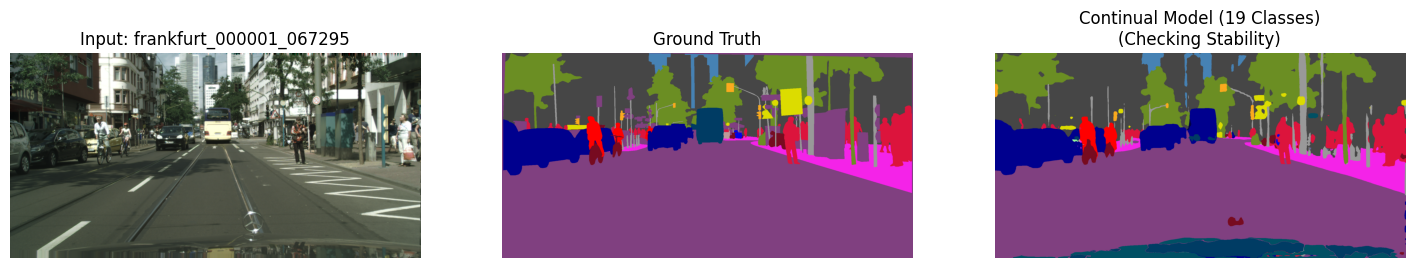

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import os
from PIL import Image
import torchvision.transforms as T
import torch.nn.functional as F

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_ROOT = "/content/drive/MyDrive/CSS/PIDNet/data/cityscapes"
CITY = "frankfurt"
FILE_ID = "frankfurt_000001_067295"

# Construct paths
input_path = os.path.join(DATA_ROOT, "leftImg8bit", "val", CITY, f"{FILE_ID}_leftImg8bit.png")
gt_path = os.path.join(DATA_ROOT, "gtFine", "val", CITY, f"{FILE_ID}_gtFine_labelIds.png")

# Palette for 19 Classes (Up to Bicycle)
CITYSCAPES_PALETTE = np.array([
    [128, 64, 128],  # 0: road
    [244, 35, 232],  # 1: sidewalk
    [70, 70, 70],    # 2: building
    [102, 102, 156], # 3: wall
    [190, 153, 153], # 4: fence
    [153, 153, 153], # 5: pole
    [250, 170, 30],  # 6: traffic light
    [220, 220, 0],   # 7: traffic sign
    [107, 142, 35],  # 8: vegetation
    [152, 251, 152], # 9: terrain
    [70, 130, 180],  # 10: sky
    [220, 20, 60],   # 11: person
    [255, 0, 0],     # 12: rider
    [0, 0, 142],     # 13: car
    [0, 0, 70],      # 14: truck
    [0, 60, 100],    # 15: Bus
    [0, 80, 100],    # 16: Train
    [0, 0, 230],     # 17: Motorcycle
    [119, 11, 32]    # 18: Bicycle (New Class)
], dtype=np.uint8)

def colorize(mask):
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for label_id in range(len(CITYSCAPES_PALETTE)):
        if label_id < 20:
            color_mask[mask == label_id] = CITYSCAPES_PALETTE[label_id]
    return color_mask

# ==========================================
# 2. INFERENCE
# ==========================================
if not os.path.exists(input_path):
    print(f"Error: Image not found at {input_path}")
else:
    print(f"=> Loading specific image: {FILE_ID}...")

    # Load
    raw_img = Image.open(input_path).convert("RGB")
    raw_lbl = np.array(Image.open(gt_path), dtype=np.uint8)

    # Preprocess
    img_tensor = img_tf(raw_img).unsqueeze(0).cuda()

    model.eval()
    with torch.no_grad():
        out = model.forward_with_new(img_tensor)

        l15 = F.interpolate(out["logits_15"], raw_lbl.shape, mode='bilinear', align_corners=True)
        lnew = F.interpolate(out["logits_new_2ch"], raw_lbl.shape, mode='bilinear', align_corners=True)

        # --- FUSE 5-WAY LOGIC (19 Classes) ---
        probs_new = torch.softmax(lnew, dim=1)

        # Check Bus(1), Train(2), Motor(3), Bike(4)
        # slice [:, 1:] gets all active new classes
        max_new_val, max_new_idx = torch.max(probs_new[:, 1:], dim=1)

        # Map 0->15, 1->16, 2->17, 3->18
        pred_new_mapped = max_new_idx + 15
        pred_base_tensor = l15.argmax(1)

        pred_fused_tensor = torch.where(max_new_val >= 0.55, pred_new_mapped, pred_base_tensor)
        pred_fused = pred_fused_tensor.squeeze(0).cpu().numpy()

    # ==========================================
    # 3. VISUALIZE
    # ==========================================
    # Denormalize Input
    vis_img = np.array(raw_img)

    # Prepare GT
    gt_vis_map = np.zeros_like(raw_lbl)
    # Using the ID_MAP from the training cell
    # Ensure ID_MAP is defined or redefine it here
    if 'ID_MAP' not in locals():
        ID_MAP = {
            7:0, 8:1, 11:2, 12:3, 13:4, 17:5, 19:6, 20:7,
            21:8, 22:9, 23:10, 24:11, 25:12, 26:13, 27:14,
            CLASS_ID_BUS: 15,
            CLASS_ID_TRAIN: 16,
            CLASS_ID_MOTOR: 17,
            CLASS_ID_BICYCLE: 18
        }

    for k, v in ID_MAP.items(): gt_vis_map[raw_lbl == k] = v

    # Colorize
    vis_gt = colorize(gt_vis_map)
    vis_pred = colorize(pred_fused)

    # Plot
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    axs[0].imshow(vis_img)
    axs[0].set_title(f"Input: {FILE_ID}")
    axs[0].axis('off')

    axs[1].imshow(vis_gt)
    axs[1].set_title("Ground Truth")
    axs[1].axis('off')

    axs[2].imshow(vis_pred)
    axs[2].set_title("Continual Model (19 Classes)\n(Checking Stability)")
    axs[2].axis('off')

    plt.show()

## PIDNet-M

15-16classes

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torch.cuda.amp import GradScaler, autocast
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
import numpy as np
import os
import glob
from tqdm import tqdm
from models.pidnet_cl import PIDNetCL

# ==========================================
# 1. SETUP: RGB DATASET
# ==========================================
DATA_ROOT = "/content/drive/MyDrive/CSS/PIDNet/data/cityscapes"
NEW_CLASS_ID = 28
img_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class CityscapesCL(Dataset):
    def __init__(self, root, split="train"):
        self.img_dir = os.path.join(root, "leftImg8bit", split)
        self.gt_dir = os.path.join(root, "gtFine", split)
        self.items = []
        if os.path.exists(self.img_dir):
            for city in sorted(os.listdir(self.img_dir)):
                imgs = sorted(glob.glob(os.path.join(self.img_dir, city, "*_leftImg8bit.png")))
                for ip in imgs:
                    gp = os.path.join(self.gt_dir, city, os.path.basename(ip).replace("_leftImg8bit.png", "_gtFine_labelIds.png"))
                    if os.path.exists(gp): self.items.append((ip, gp))

    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        ip, gp = self.items[idx]
        img = img_tf(Image.open(ip).convert("RGB"))
        lbl = np.array(Image.open(gp), dtype=np.uint8)

        # Binary Target for Training (Bus vs Rest)
        tgt = np.full_like(lbl, 255)
        valid_bg = [7,8,11,12,13,17,19,20,21,22,23,24,25,26,27]
        for c in valid_bg: tgt[lbl == c] = 0
        tgt[lbl == NEW_CLASS_ID] = 1
        return img, torch.from_numpy(tgt).long(), lbl

# ==========================================
# 2. MODEL: LOAD & FREEZE (PIDNet-M)
# ==========================================
print("=> Initializing PIDNet-M & Loading Base Weights...")
# Correct: planes=64 for Medium
model = PIDNetCL(m=2, n=3, num_classes=15, planes=64, ppm_planes=96, head_planes=128, augment=True)

ckpt = torch.load("/content/drive/MyDrive/CSS/PIDNet/output/cityscapes/pidnet_m_custom_15/best.pt", map_location="cpu")
state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt
state_dict = {k.replace('module.', '').replace('model.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict, strict=False)

model.cuda()

# --- CRITICAL FIX: PROTECTED BATCHNORM ---
# 1. Lock entire model (Backbone BN stats frozen)
model.eval()

# 2. Unfreeze and activate ONLY new modules
trainable_modules = ["layer3_d_new","layer4_d_new","diff3_new","diff4_new","seghead_new"]
for name, m in model.named_modules():
    if any(t in name for t in trainable_modules):
        m.train() # Allow BN updates/Dropout for NEW branch only
        for p in m.parameters():
            p.requires_grad = True
    else:
        for p in m.parameters():
            p.requires_grad = False
# -----------------------------------------

# ==========================================
# 3. TRAIN: SUBSET ONLY
# ==========================================
print("=> Preparing Training Data...")
train_set = CityscapesCL(DATA_ROOT, "train")
bus_indices = [i for i, (_, gp) in enumerate(train_set.items) if (np.array(Image.open(gp)) == NEW_CLASS_ID).any()]

# Note: Keeping batch_size=6. If OOM occurs, change to 4.
train_loader = DataLoader(Subset(train_set, bus_indices), batch_size=6, shuffle=True, num_workers=2, pin_memory=True)

print(f"=> Retraining New Branch (RGB) on {len(bus_indices)} images...")
optim = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
crit = nn.CrossEntropyLoss(ignore_index=255)
scaler = GradScaler(enabled=True)

for epoch in range(5):
    for i, (img, tgt, _) in enumerate(train_loader):
        img, tgt = img.cuda(), tgt.cuda()
        with autocast(enabled=True):
            out = model.forward_with_new(img)
            loss = crit(out["logits_new_2ch"], tgt)
        optim.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()
    print(f"   Epoch {epoch+1} Loss: {loss.item():.4f}")

# --- ADDED SAVE STEP ---
torch.save(model.state_dict(), "step1_result_m.pt")
print("=> Saved Step 1 (Medium) result to 'step1_result_m.pt'")

# ==========================================
# 4. EVALUATE: DUAL MODE (LEGACY vs HONEST)
# ==========================================
print("\n=> Running Dual-Mode Evaluation (Validation Set)...")
val_set = CityscapesCL(DATA_ROOT, "val")
val_loader = DataLoader(val_set, batch_size=4, shuffle=False, num_workers=2)

@torch.no_grad()
def fuse(o15, onew, tau=0.55):
    p_new = torch.softmax(onew, dim=1)[:, 1:2]
    return torch.where(p_new >= tau, torch.tensor(15).to(p_new.device), o15.argmax(1, keepdim=True)).squeeze(1)

model.eval()
cm_legacy = torch.zeros((15, 15), dtype=torch.long).cuda()
cm_honest = torch.zeros((16, 16), dtype=torch.long).cuda()

id_map_15 = {7:0,8:1,11:2,12:3,13:4,17:5,19:6,20:7,21:8,22:9,23:10,24:11,25:12,26:13,27:14}

for img, _, raw_lbl in tqdm(val_loader):
    img = img.cuda()
    raw_lbl = raw_lbl.long().cuda()

    out = model.forward_with_new(img)
    l15 = F.interpolate(out["logits_15"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)
    lnew = F.interpolate(out["logits_new_2ch"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)
    pred = fuse(l15, lnew, tau=0.55)

    tgt_16 = torch.full_like(raw_lbl, 255)
    for k, v in id_map_15.items(): tgt_16[raw_lbl == k] = v
    tgt_16[raw_lbl == NEW_CLASS_ID] = 15

    tgt_15 = tgt_16.clone()
    tgt_15[tgt_15 == 15] = 255

    mask16 = tgt_16 != 255
    if mask16.any():
        cm_honest += torch.bincount(tgt_16[mask16]*16 + pred[mask16], minlength=256).view(16,16)

    mask15 = tgt_15 != 255
    if mask15.any():
        p15_view = pred[mask15]
        valid_p = p15_view < 15
        if valid_p.any():
            cm_legacy += torch.bincount(tgt_15[mask15][valid_p]*15 + p15_view[valid_p], minlength=225).view(15,15)

iou_leg = torch.diag(cm_legacy) / (cm_legacy.sum(1) + cm_legacy.sum(0) - torch.diag(cm_legacy) + 1e-6)
iou_hon = torch.diag(cm_honest) / (cm_honest.sum(1) + cm_honest.sum(0) - torch.diag(cm_honest) + 1e-6)

print(f"\nLegacy mIoU (15 Class): {iou_leg.mean().item()*100:.2f}%")
print(f"Honest mIoU (16 Class): {iou_hon.mean().item()*100:.2f}%")
print(f"Truck (Legacy): {iou_leg[14].item()*100:.2f}% | Bus (Honest): {iou_hon[15].item()*100:.2f}%")

=> Initializing PIDNet-M & Loading Base Weights...
=> Preparing Training Data...
=> Retraining New Branch (RGB) on 274 images...


/tmp/ipython-input-3546032204.py:92: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)
/tmp/ipython-input-3546032204.py:97: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


   Epoch 1 Loss: 0.0269
   Epoch 2 Loss: 0.0273
   Epoch 3 Loss: 0.0196
   Epoch 4 Loss: 0.0086
   Epoch 5 Loss: 0.0185
=> Saved Step 1 (Medium) result to 'step1_result_m.pt'

=> Running Dual-Mode Evaluation (Validation Set)...


100%|██████████| 125/125 [06:50<00:00,  3.28s/it]


Legacy mIoU (15 Class): 72.73%
Honest mIoU (16 Class): 68.98%
Truck (Legacy): 52.68% | Bus (Honest): 37.17%


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torch.cuda.amp import GradScaler, autocast
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
import numpy as np
import os, glob
from tqdm import tqdm
from models.pidnet_cl import PIDNetCL

# ==========================================
# 1. SETUP: RGB DATASET (Official Config)
# ==========================================
DATA_ROOT = "/content/drive/MyDrive/CSS/PIDNet/data/cityscapes"
NEW_CLASS_ID = 28
img_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # RGB Stats
])

class CityscapesCL(Dataset):
    def __init__(self, root, split="train"):
        self.img_dir = os.path.join(root, "leftImg8bit", split)
        self.gt_dir = os.path.join(root, "gtFine", split)
        self.items = []
        # Find images
        if os.path.exists(self.img_dir):
            for city in sorted(os.listdir(self.img_dir)):
                imgs = sorted(glob.glob(os.path.join(self.img_dir, city, "*_leftImg8bit.png")))
                for ip in imgs:
                    gp = os.path.join(self.gt_dir, city, os.path.basename(ip).replace("_leftImg8bit.png", "_gtFine_labelIds.png"))
                    if os.path.exists(gp): self.items.append((ip, gp))

    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        ip, gp = self.items[idx]
        # RGB Loading (Matches Official PIDNet training)
        img = img_tf(Image.open(ip).convert("RGB"))
        lbl = np.array(Image.open(gp), dtype=np.uint8)

        # Binary Target for Training (Bus vs Rest)
        tgt = np.full_like(lbl, 255)
        valid_bg = [7,8,11,12,13,17,19,20,21,22,23,24,25,26,27]
        for c in valid_bg: tgt[lbl == c] = 0
        tgt[lbl == NEW_CLASS_ID] = 1
        return img, torch.from_numpy(tgt).long(), lbl # Return raw label for eval

# ==========================================
# 2. MODEL: LOAD & FREEZE
# ==========================================
print("=> Initializing Model & Loading Base Weights...")
model = PIDNetCL(m=2, n=3, num_classes=15, planes=64, ppm_planes=96, head_planes=128, augment=True)
ckpt = torch.load("/content/drive/MyDrive/CSS/PIDNet/output/cityscapes/pidnet_m_custom_15/best.pt", map_location="cpu")
state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt
state_dict = {k.replace('module.', '').replace('model.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict, strict=False)

# Freeze Old, Thaw New
for name, p in model.named_parameters():
    p.requires_grad = any(t in name for t in ["layer3_d_new","layer4_d_new","diff3_new","diff4_new","seghead_new"])
model.cuda()
model.train()

# ==========================================
# 3. TRAIN: SUBSET ONLY
# ==========================================
print("=> Preparing Training Data...")
train_set = CityscapesCL(DATA_ROOT, "train")
bus_indices = [i for i, (_, gp) in enumerate(train_set.items) if (np.array(Image.open(gp)) == NEW_CLASS_ID).any()]
train_loader = DataLoader(Subset(train_set, bus_indices), batch_size=6, shuffle=True, num_workers=2, pin_memory=True)

print(f"=> Retraining New Branch (RGB) on {len(bus_indices)} images...")
optim = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
crit = nn.CrossEntropyLoss(ignore_index=255)
scaler = GradScaler(enabled=True)

for epoch in range(5): # Fast retraining (5 epochs of the subset is enough to recover)
    for i, (img, tgt, _) in enumerate(train_loader):
        img, tgt = img.cuda(), tgt.cuda()
        with autocast(enabled=True):
            out = model.forward_with_new(img)
            loss = crit(out["logits_new_2ch"], tgt)
        optim.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()
    print(f"   Epoch {epoch+1} Loss: {loss.item():.4f}")

# ==========================================
# 4. EVALUATE: DUAL MODE (LEGACY vs HONEST)
# ==========================================
print("\n=> Running Dual-Mode Evaluation (Validation Set)...")
val_set = CityscapesCL(DATA_ROOT, "val")
val_loader = DataLoader(val_set, batch_size=4, shuffle=False, num_workers=2)

@torch.no_grad()
def fuse(o15, onew, tau=0.55):
    p_new = torch.softmax(onew, dim=1)[:, 1:2]
    return torch.where(p_new >= tau, torch.tensor(15).to(p_new.device), o15.argmax(1, keepdim=True)).squeeze(1)

model.eval()
# Confusion Matrices
cm_legacy = torch.zeros((15, 15), dtype=torch.long).cuda() # Original 15 classes
cm_honest = torch.zeros((16, 16), dtype=torch.long).cuda() # All 16 classes

id_map_15 = {7:0,8:1,11:2,12:3,13:4,17:5,19:6,20:7,21:8,22:9,23:10,24:11,25:12,26:13,27:14}

for img, _, raw_lbl in tqdm(val_loader):
    img = img.cuda()
    raw_lbl = raw_lbl.long().cuda()

    # 1. Forward & Up
    out = model.forward_with_new(img)
    l15 = F.interpolate(out["logits_15"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)
    lnew = F.interpolate(out["logits_new_2ch"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)
    pred = fuse(l15, lnew, tau=0.55) # Use 0.55 or adjust higher if Truck drops too much

    # 2. Prepare Targets (16 Class)
    tgt_16 = torch.full_like(raw_lbl, 255)
    for k, v in id_map_15.items(): tgt_16[raw_lbl == k] = v
    tgt_16[raw_lbl == NEW_CLASS_ID] = 15

    # 3. Prepare Targets (15 Class Legacy - Ignore Bus)
    tgt_15 = tgt_16.clone()
    tgt_15[tgt_15 == 15] = 255 # IGNORE BUS PIXELS (Matches Base Model Evaluation)

    # 4. Update Matrices
    mask16 = tgt_16 != 255
    if mask16.any():
        cm_honest += torch.bincount(tgt_16[mask16]*16 + pred[mask16], minlength=256).view(16,16)

    mask15 = tgt_15 != 255
    if mask15.any():
        # Map predictions of "15" (Bus) back to something else or just mask them?
        # In legacy mode, if we predict "Bus", it's technically a "Non-15-class" prediction.
        # But usually we just calculate IoU on 0-14.
        p15_view = pred[mask15]
        # Only count if prediction is 0-14 (Valid Legacy)
        valid_p = p15_view < 15
        if valid_p.any():
            cm_legacy += torch.bincount(tgt_15[mask15][valid_p]*15 + p15_view[valid_p], minlength=225).view(15,15)

# Calculate Scores
iou_leg = torch.diag(cm_legacy) / (cm_legacy.sum(1) + cm_legacy.sum(0) - torch.diag(cm_legacy) + 1e-6)
iou_hon = torch.diag(cm_honest) / (cm_honest.sum(1) + cm_honest.sum(0) - torch.diag(cm_honest) + 1e-6)

print(f"\nLegacy mIoU (15 Class): {iou_leg.mean().item()*100:.2f}%  -- Should be around 79%")
print(f"Honest mIoU (16 Class): {iou_hon.mean().item()*100:.2f}%  -- Real System Performance")
print(f"Truck (Legacy): {iou_leg[14].item()*100:.2f}% | Bus (Honest): {iou_hon[15].item()*100:.2f}%")

=> Initializing Model & Loading Base Weights...
=> Preparing Training Data...
=> Retraining New Branch (RGB) on 274 images...


/tmp/ipython-input-1397205454.py:77: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)
/tmp/ipython-input-1397205454.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


   Epoch 1 Loss: 0.0889
   Epoch 2 Loss: 0.0884
   Epoch 3 Loss: 0.0104
   Epoch 4 Loss: 0.0543
   Epoch 5 Loss: 0.0188

=> Running Dual-Mode Evaluation (Validation Set)...


100%|██████████| 125/125 [00:43<00:00,  2.90it/s]


Legacy mIoU (15 Class): 79.14%  -- Should be around 79%
Honest mIoU (16 Class): 74.80%  -- Real System Performance
Truck (Legacy): 76.23% | Bus (Honest): 38.71%


In [ ]:
# Save the model from Step 1 (15 Base + 1 New Branch)
torch.save(model.state_dict(), "step1_result.pt")
print("=> Step 1 model saved as 'step1_result.pt'")

=> Step 1 model saved as 'step1_result.pt'


16-17

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torch.cuda.amp import GradScaler, autocast
import numpy as np
import os
import glob
from PIL import Image
from tqdm import tqdm
import torchvision.transforms as T
from models.pidnet_cl import PIDNetCL
from models.model_utils import segmenthead

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_ROOT = "/content/drive/MyDrive/CSS/PIDNet/data/cityscapes"
# Point this to your Step 1 result
PREV_CKPT_PATH = "/content/PIDNet/step1_result.pt"
SAVE_PATH = "step2_result_17classes.pt"

# IDs
CLASS_ID_BUS = 28
CLASS_ID_TRAIN = 31

img_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 2. DATASET: 3-Way Target (BG, Bus, Train)
# ==========================================
class CityscapesCL_Step2(torch.utils.data.Dataset):
    def __init__(self, root, split="train"):
        self.img_dir = os.path.join(root, "leftImg8bit", split)
        self.gt_dir = os.path.join(root, "gtFine", split)
        self.items = []
        if os.path.exists(self.img_dir):
            for city in sorted(os.listdir(self.img_dir)):
                imgs = sorted(glob.glob(os.path.join(self.img_dir, city, "*_leftImg8bit.png")))
                for ip in imgs:
                    gp = os.path.join(self.gt_dir, city, os.path.basename(ip).replace("_leftImg8bit.png", "_gtFine_labelIds.png"))
                    if os.path.exists(gp): self.items.append((ip, gp))

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        ip, gp = self.items[idx]
        img = img_tf(Image.open(ip).convert("RGB"))
        lbl = np.array(Image.open(gp), dtype=np.uint8)

        # 0 = Background (Base classes)
        # 1 = Bus (Keep Memory)
        # 2 = Train (New Learn)
        tgt = np.full_like(lbl, 255)

        # Original 15 context classes are Background for this branch
        valid_bg = [7,8,11,12,13,17,19,20,21,22,23,24,25,26,27]
        for c in valid_bg: tgt[lbl == c] = 0

        tgt[lbl == CLASS_ID_BUS] = 1   # Bus is Class 1 in this branch
        tgt[lbl == CLASS_ID_TRAIN] = 2 # Train is Class 2 in this branch

        return img, torch.from_numpy(tgt).long(), lbl

# ==========================================
# 3. MODEL SETUP: EXPAND THE BRANCH
# ==========================================
print("=> Loading Step 1 Model...")
model = PIDNetCL(m=2, n=3, num_classes=15, planes=64, ppm_planes=96, head_planes=128, augment=True)
ckpt = torch.load(PREV_CKPT_PATH, map_location="cpu")
state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt
state_dict = {k.replace('module.', '').replace('model.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict, strict=False)

print("=> Expanding New Branch Head (2 -> 3 channels)...")

# 1. Access the specific final layer (conv2) inside the head
old_layer = model.seghead_new.conv2

# 2. Get old weights
old_w = old_layer.weight.data # [2, 128, 1, 1]
old_b = old_layer.bias.data   # [2]

# 3. Create new layer with 3 outputs
# We use old_layer.in_channels (128) to ensure it matches the head_planes
new_layer = nn.Conv2d(old_layer.in_channels, 3, kernel_size=1, padding=0, bias=True)

# 4. Copy Weights (Preserve Bus Memory)
# Copy BG (idx 0) and Bus (idx 1)
new_layer.weight.data[:2] = old_w
new_layer.bias.data[:2] = old_b
# Train (idx 2) is randomly initialized

print(f"   Head Expanded: {old_w.shape} -> {new_layer.weight.data.shape}")

# 5. Swap the layer
model.seghead_new.conv2 = new_layer

model.cuda()

# ==========================================
# 4. TRAIN (Protected BN)
# ==========================================
model.eval()
trainable_modules = ["layer3_d_new", "layer4_d_new", "diff3_new", "diff4_new", "seghead_new"]

for name, m in model.named_modules():
    if any(t in name for t in trainable_modules):
        m.train()
        for p in m.parameters():
            p.requires_grad = True
    else:
        for p in m.parameters():
            p.requires_grad = False

print(f"\n=> Retraining for Bus (Maintain) + Train (Learn)...")
train_set = CityscapesCL_Step2(DATA_ROOT, "train")
# Train on images that have EITHER Bus OR Train
active_indices = [i for i, (_, gp) in enumerate(train_set.items) if
                  (np.array(Image.open(gp)) == CLASS_ID_BUS).any() or
                  (np.array(Image.open(gp)) == CLASS_ID_TRAIN).any()]

train_loader = DataLoader(Subset(train_set, active_indices), batch_size=6, shuffle=True, num_workers=2, pin_memory=True)

optim = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
crit = nn.CrossEntropyLoss(ignore_index=255)
scaler = GradScaler(enabled=True)

for epoch in range(5):
    epoch_loss = 0
    for i, (img, tgt, _) in enumerate(train_loader):
        img, tgt = img.cuda(), tgt.cuda()
        with autocast(enabled=True):
            # Returns 3 channels now
            out = model.forward_with_new(img)
            # We access 'logits_new_2ch' because that's the key name in pidnet_cl.py
            loss = crit(out["logits_new_2ch"], tgt)

        optim.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()
        epoch_loss += loss.item()
    print(f"   Epoch {epoch+1} Loss: {epoch_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), SAVE_PATH)

# ==========================================
# 5. EVALUATION (3-WAY FUSION)
# ==========================================
print("\n=> Running Evaluation...")
val_set_eval = CityscapesCL_Step2(DATA_ROOT, "val")
val_loader = DataLoader(val_set_eval, batch_size=4, shuffle=False, num_workers=2)

ID_MAP = {
    7:0, 8:1, 11:2, 12:3, 13:4, 17:5, 19:6, 20:7,
    21:8, 22:9, 23:10, 24:11, 25:12, 26:13, 27:14,
    CLASS_ID_BUS: 15,
    CLASS_ID_TRAIN: 16
}

@torch.no_grad()
def fuse_3way(logits_base, logits_new, tau=0.55):
    # logits_base: [B, 15, H, W]
    # logits_new:  [B, 3, H, W] -> (BG, Bus, Train)

    probs_new = torch.softmax(logits_new, dim=1)

    # Check max probability among the "Active" classes (Bus & Train)
    # slice [:, 1:] gets columns 1 (Bus) and 2 (Train)
    max_new_val, max_new_idx = torch.max(probs_new[:, 1:], dim=1)

    pred_base = logits_base.argmax(1)

    # if max_new_idx is 0 -> it refers to Bus (Class 15)
    # if max_new_idx is 1 -> it refers to Train (Class 16)
    pred_new_mapped = max_new_idx + 15

    return torch.where(max_new_val >= tau, pred_new_mapped, pred_base)

model.eval()
cm = torch.zeros((17, 17), dtype=torch.long).cuda()

for img, _, raw_lbl in tqdm(val_loader):
    img = img.cuda()
    raw_lbl = raw_lbl.long().cuda()

    out = model.forward_with_new(img)
    l_base = F.interpolate(out["logits_15"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)
    l_new = F.interpolate(out["logits_new_2ch"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)

    pred = fuse_3way(l_base, l_new)

    tgt = torch.full_like(raw_lbl, 255)
    for k, v in ID_MAP.items():
        tgt[raw_lbl == k] = v

    mask = tgt != 255
    if mask.any():
        cm += torch.bincount(tgt[mask]*17 + pred[mask], minlength=289).view(17,17)

iou_per_class = torch.diag(cm) / (cm.sum(1) + cm.sum(0) - torch.diag(cm) + 1e-6)

print("\n" + "="*40)
print(f"Legacy (15 Classes) mIoU:   {iou_per_class[0:15].mean().item()*100:.2f}%")
print(f"Step 1 (16 Classes) mIoU:   {iou_per_class[0:16].mean().item()*100:.2f}% (Includes Bus)")
print(f"Actual (17 Classes) mIoU:   {iou_per_class[0:17].mean().item()*100:.2f}% (Includes Train)")
print("="*40)
print(f"Bus IoU:   {iou_per_class[15].item()*100:.2f}%")
print(f"Train IoU: {iou_per_class[16].item()*100:.2f}%")

=> Loading Step 1 Model...
=> Expanding New Branch Head (2 -> 3 channels)...
   Head Expanded: torch.Size([2, 128, 1, 1]) -> torch.Size([3, 128, 1, 1])

=> Retraining for Bus (Maintain) + Train (Learn)...


/tmp/ipython-input-696588115.py:130: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)
/tmp/ipython-input-696588115.py:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


   Epoch 1 Loss: 0.0666
   Epoch 2 Loss: 0.0438
   Epoch 3 Loss: 0.0375
   Epoch 4 Loss: 0.0303
   Epoch 5 Loss: 0.0251

=> Running Evaluation...


100%|██████████| 125/125 [00:43<00:00,  2.88it/s]


Legacy (15 Classes) mIoU:   77.37%
Step 1 (16 Classes) mIoU:   75.29% (Includes Bus)
Actual (17 Classes) mIoU:   72.03% (Includes Train)
Bus IoU:   44.08%
Train IoU: 19.80%


17-18

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torch.cuda.amp import GradScaler, autocast
import numpy as np
import os
import glob
from PIL import Image
from tqdm import tqdm
import torchvision.transforms as T
from models.pidnet_cl import PIDNetCL
from models.model_utils import segmenthead

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_ROOT = "/content/drive/MyDrive/CSS/PIDNet/data/cityscapes"

# IMPORTANT: Point this to the result of STEP 2
PREV_CKPT_PATH = "step2_result_17classes.pt"
SAVE_PATH = "step3_result_18classes.pt"

# IDs
CLASS_ID_BUS = 28
CLASS_ID_TRAIN = 31
CLASS_ID_MOTOR = 32 # The New Class (18th)

img_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 2. DATASET: 4-Way Target (BG, Bus, Train, Motor)
# ==========================================
class CityscapesCL_Step3(torch.utils.data.Dataset):
    def __init__(self, root, split="train"):
        self.img_dir = os.path.join(root, "leftImg8bit", split)
        self.gt_dir = os.path.join(root, "gtFine", split)
        self.items = []
        if os.path.exists(self.img_dir):
            for city in sorted(os.listdir(self.img_dir)):
                imgs = sorted(glob.glob(os.path.join(self.img_dir, city, "*_leftImg8bit.png")))
                for ip in imgs:
                    gp = os.path.join(self.gt_dir, city, os.path.basename(ip).replace("_leftImg8bit.png", "_gtFine_labelIds.png"))
                    if os.path.exists(gp): self.items.append((ip, gp))

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        ip, gp = self.items[idx]
        img = img_tf(Image.open(ip).convert("RGB"))
        lbl = np.array(Image.open(gp), dtype=np.uint8)

        # 0 = Background (Base classes)
        # 1 = Bus
        # 2 = Train
        # 3 = Motorcycle (New)
        tgt = np.full_like(lbl, 255)

        # Original 15 context classes are Background
        valid_bg = [7,8,11,12,13,17,19,20,21,22,23,24,25,26,27]
        for c in valid_bg: tgt[lbl == c] = 0

        tgt[lbl == CLASS_ID_BUS] = 1
        tgt[lbl == CLASS_ID_TRAIN] = 2
        tgt[lbl == CLASS_ID_MOTOR] = 3 # New Target

        return img, torch.from_numpy(tgt).long(), lbl

# ==========================================
# 3. MODEL SETUP: EXPAND TO 4 CHANNELS
# ==========================================
print("=> Loading Step 2 Model...")
# Base is always 15
model = PIDNetCL(m=2, n=3, num_classes=15, planes=64, ppm_planes=96, head_planes=128, augment=True)

# Use the specific logic for Step 3 expansion (needs to handle the 3-channel head from step 2)
# But wait! PIDNetCL init creates a 2-channel head by default.
# We need to manually expand it to 3 channels FIRST so we can load the Step 2 weights.
model.seghead_new = segmenthead(64 * 2, 128, 3) # Pre-expand to match Step 2 checkpoint

ckpt = torch.load(PREV_CKPT_PATH, map_location="cpu")
state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt
state_dict = {k.replace('module.', '').replace('model.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict, strict=True) # strict=True should work now

print("=> Expanding Head (3 -> 4 channels)...")
old_layer = model.seghead_new.conv2
old_w = old_layer.weight.data # [3, 128, 1, 1]
old_b = old_layer.bias.data   # [3]

# Create new layer with 4 outputs
new_layer = nn.Conv2d(old_layer.in_channels, 4, kernel_size=1, padding=0, bias=True)

# Copy Weights (Preserve BG, Bus, Train)
# Copy indices 0, 1, 2
new_layer.weight.data[:3] = old_w
new_layer.bias.data[:3] = old_b
# Index 3 (Motor) is random

print(f"   Head Expanded: {old_w.shape} -> {new_layer.weight.data.shape}")
model.seghead_new.conv2 = new_layer
model.cuda()

# ==========================================
# 4. TRAIN (Protected BN)
# ==========================================
model.eval()
trainable_modules = ["layer3_d_new", "layer4_d_new", "diff3_new", "diff4_new", "seghead_new"]
for name, m in model.named_modules():
    if any(t in name for t in trainable_modules):
        m.train()
        for p in m.parameters():
            p.requires_grad = True
    else:
        for p in m.parameters():
            p.requires_grad = False

print(f"\n=> Retraining for Bus+Train+Motor...")
train_set = CityscapesCL_Step3(DATA_ROOT, "train")
# Train on images containing ANY of the special classes
active_indices = [i for i, (_, gp) in enumerate(train_set.items) if
                  (np.array(Image.open(gp)) == CLASS_ID_BUS).any() or
                  (np.array(Image.open(gp)) == CLASS_ID_TRAIN).any() or
                  (np.array(Image.open(gp)) == CLASS_ID_MOTOR).any()]

train_loader = DataLoader(Subset(train_set, active_indices), batch_size=6, shuffle=True, num_workers=2, pin_memory=True)

optim = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
crit = nn.CrossEntropyLoss(ignore_index=255)
scaler = GradScaler(enabled=True)

for epoch in range(5):
    epoch_loss = 0
    for i, (img, tgt, _) in enumerate(train_loader):
        img, tgt = img.cuda(), tgt.cuda()
        with autocast(enabled=True):
            out = model.forward_with_new(img)
            loss = crit(out["logits_new_2ch"], tgt)
        optim.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()
        epoch_loss += loss.item()
    print(f"   Epoch {epoch+1} Loss: {epoch_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), SAVE_PATH)

# ==========================================
# 5. EVALUATION (4-WAY FUSION)
# ==========================================
print("\n=> Running Evaluation...")
val_set_eval = CityscapesCL_Step3(DATA_ROOT, "val")
val_loader = DataLoader(val_set_eval, batch_size=4, shuffle=False, num_workers=2)

ID_MAP = {
    7:0, 8:1, 11:2, 12:3, 13:4, 17:5, 19:6, 20:7,
    21:8, 22:9, 23:10, 24:11, 25:12, 26:13, 27:14,
    CLASS_ID_BUS: 15,
    CLASS_ID_TRAIN: 16,
    CLASS_ID_MOTOR: 17
}

@torch.no_grad()
def fuse_4way(logits_base, logits_new, tau=0.55):
    # logits_new: [B, 4, H, W] -> (BG, Bus, Train, Motor)
    probs_new = torch.softmax(logits_new, dim=1)

    # Check max probability among "Active" classes (Bus, Train, Motor)
    # slice [:, 1:] gets columns 1, 2, 3
    max_new_val, max_new_idx = torch.max(probs_new[:, 1:], dim=1)

    # Mapping:
    # max_new_idx 0 (Bus)   -> 15
    # max_new_idx 1 (Train) -> 16
    # max_new_idx 2 (Motor) -> 17
    pred_new_mapped = max_new_idx + 15

    pred_base = logits_base.argmax(1)
    return torch.where(max_new_val >= tau, pred_new_mapped, pred_base)

model.eval()
cm = torch.zeros((18, 18), dtype=torch.long).cuda()

for img, _, raw_lbl in tqdm(val_loader):
    img = img.cuda()
    raw_lbl = raw_lbl.long().cuda()

    out = model.forward_with_new(img)
    l_base = F.interpolate(out["logits_15"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)
    l_new = F.interpolate(out["logits_new_2ch"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)

    pred = fuse_4way(l_base, l_new)

    tgt = torch.full_like(raw_lbl, 255)
    for k, v in ID_MAP.items(): tgt[raw_lbl == k] = v

    mask = tgt != 255
    if mask.any():
        cm += torch.bincount(tgt[mask]*18 + pred[mask], minlength=18*18).view(18,18)

iou_per_class = torch.diag(cm) / (cm.sum(1) + cm.sum(0) - torch.diag(cm) + 1e-6)

print("\n" + "="*40)
print(f"Legacy (15) mIoU: {iou_per_class[0:15].mean().item()*100:.2f}%")
print(f"Bus IoU:   {iou_per_class[15].item()*100:.2f}%")
print(f"Train IoU: {iou_per_class[16].item()*100:.2f}%")
print(f"Motor IoU: {iou_per_class[17].item()*100:.2f}%")

=> Loading Step 2 Model...
=> Expanding Head (3 -> 4 channels)...
   Head Expanded: torch.Size([3, 128, 1, 1]) -> torch.Size([4, 128, 1, 1])

=> Retraining for Bus+Train+Motor...


/tmp/ipython-input-455394540.py:133: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)
/tmp/ipython-input-455394540.py:139: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


   Epoch 1 Loss: 0.0300
   Epoch 2 Loss: 0.0199
   Epoch 3 Loss: 0.0165
   Epoch 4 Loss: 0.0137
   Epoch 5 Loss: 0.0120

=> Running Evaluation...


100%|██████████| 125/125 [00:43<00:00,  2.86it/s]


Legacy (15) mIoU: 77.45%
Bus IoU:   48.93%
Train IoU: 24.03%
Motor IoU: 44.51%


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torch.cuda.amp import GradScaler, autocast
import numpy as np
import os
import glob
from PIL import Image
from tqdm import tqdm
import torchvision.transforms as T
from models.pidnet_cl import PIDNetCL
from models.model_utils import segmenthead

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_ROOT = "/content/drive/MyDrive/CSS/PIDNet/data/cityscapes"
PREV_CKPT_PATH = "step2_result_17classes.pt"
SAVE_PATH = "step3_result_18classes.pt"

# IDs
CLASS_ID_BUS = 28
CLASS_ID_TRAIN = 31
CLASS_ID_MOTOR = 32 # New Class

img_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 2. DATASET: 4-Way Target
# ==========================================
class CityscapesCL_Step3(torch.utils.data.Dataset):
    def __init__(self, root, split="train"):
        self.img_dir = os.path.join(root, "leftImg8bit", split)
        self.gt_dir = os.path.join(root, "gtFine", split)
        self.items = []
        if os.path.exists(self.img_dir):
            for city in sorted(os.listdir(self.img_dir)):
                imgs = sorted(glob.glob(os.path.join(self.img_dir, city, "*_leftImg8bit.png")))
                for ip in imgs:
                    gp = os.path.join(self.gt_dir, city, os.path.basename(ip).replace("_leftImg8bit.png", "_gtFine_labelIds.png"))
                    if os.path.exists(gp): self.items.append((ip, gp))

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        ip, gp = self.items[idx]
        img = img_tf(Image.open(ip).convert("RGB"))
        lbl = np.array(Image.open(gp), dtype=np.uint8)

        # 0 = Background
        # 1 = Bus, 2 = Train
        # 3 = Motorcycle (New)
        tgt = np.full_like(lbl, 255)

        valid_bg = [7,8,11,12,13,17,19,20,21,22,23,24,25,26,27]
        for c in valid_bg: tgt[lbl == c] = 0

        tgt[lbl == CLASS_ID_BUS] = 1
        tgt[lbl == CLASS_ID_TRAIN] = 2
        tgt[lbl == CLASS_ID_MOTOR] = 3

        return img, torch.from_numpy(tgt).long(), lbl

# ==========================================
# 3. MODEL SETUP (PIDNet-M)
# ==========================================
print("=> Loading Step 2 Model (Medium)...")
model = PIDNetCL(m=2, n=3, num_classes=15, planes=64, ppm_planes=96, head_planes=128, augment=True)

# CORRECT for Medium: 64*2 = 128 input channels
model.seghead_new = segmenthead(64 * 2, 128, 3)

ckpt = torch.load(PREV_CKPT_PATH, map_location="cpu")
state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt
state_dict = {k.replace('module.', '').replace('model.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict, strict=True)

print("=> Expanding Head (3 -> 4 channels)...")
old_layer = model.seghead_new.conv2
old_w = old_layer.weight.data
old_b = old_layer.bias.data

# Create new layer with 4 outputs
new_layer = nn.Conv2d(old_layer.in_channels, 4, kernel_size=1, padding=0, bias=True)

# Copy Weights (Preserve BG, Bus, Train)
new_layer.weight.data[:3] = old_w
new_layer.bias.data[:3] = old_b

print(f"   Head Expanded: {old_w.shape} -> {new_layer.weight.data.shape}")
model.seghead_new.conv2 = new_layer
model.cuda()

# ==========================================
# 4. TRAIN (Protected BN)
# ==========================================
model.eval()
trainable_modules = ["layer3_d_new", "layer4_d_new", "diff3_new", "diff4_new", "seghead_new"]
for name, m in model.named_modules():
    if any(t in name for t in trainable_modules):
        m.train()
        for p in m.parameters():
            p.requires_grad = True
    else:
        for p in m.parameters():
            p.requires_grad = False

print(f"\n=> Retraining for Bus+Train+Motor...")
train_set = CityscapesCL_Step3(DATA_ROOT, "train")
active_indices = [i for i, (_, gp) in enumerate(train_set.items) if
                  (np.array(Image.open(gp)) == CLASS_ID_BUS).any() or
                  (np.array(Image.open(gp)) == CLASS_ID_TRAIN).any() or
                  (np.array(Image.open(gp)) == CLASS_ID_MOTOR).any()]

# Batch Size 6 (Reduce to 4 if OOM)
train_loader = DataLoader(Subset(train_set, active_indices), batch_size=6, shuffle=True, num_workers=2, pin_memory=True)

optim = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
crit = nn.CrossEntropyLoss(ignore_index=255)
scaler = GradScaler(enabled=True)

for epoch in range(5):
    epoch_loss = 0
    for i, (img, tgt, _) in enumerate(train_loader):
        img, tgt = img.cuda(), tgt.cuda()
        with autocast(enabled=True):
            out = model.forward_with_new(img)
            loss = crit(out["logits_new_2ch"], tgt)
        optim.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()
        epoch_loss += loss.item()
    print(f"   Epoch {epoch+1} Loss: {epoch_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), SAVE_PATH)

# ==========================================
# 5. EVALUATION (4-WAY FUSION)
# ==========================================
print("\n=> Running Evaluation...")
val_set_eval = CityscapesCL_Step3(DATA_ROOT, "val")
val_loader = DataLoader(val_set_eval, batch_size=4, shuffle=False, num_workers=2)

ID_MAP = {
    7:0, 8:1, 11:2, 12:3, 13:4, 17:5, 19:6, 20:7,
    21:8, 22:9, 23:10, 24:11, 25:12, 26:13, 27:14,
    CLASS_ID_BUS: 15,
    CLASS_ID_TRAIN: 16,
    CLASS_ID_MOTOR: 17
}

@torch.no_grad()
def fuse_4way(logits_base, logits_new, tau=0.55):
    probs_new = torch.softmax(logits_new, dim=1)
    max_new_val, max_new_idx = torch.max(probs_new[:, 1:], dim=1)
    pred_new_mapped = max_new_idx + 15
    pred_base = logits_base.argmax(1)
    return torch.where(max_new_val >= tau, pred_new_mapped, pred_base)

model.eval()
cm = torch.zeros((18, 18), dtype=torch.long).cuda()

for img, _, raw_lbl in tqdm(val_loader):
    img = img.cuda()
    raw_lbl = raw_lbl.long().cuda()

    out = model.forward_with_new(img)
    l_base = F.interpolate(out["logits_15"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)
    l_new = F.interpolate(out["logits_new_2ch"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)

    pred = fuse_4way(l_base, l_new)

    tgt = torch.full_like(raw_lbl, 255)
    for k, v in ID_MAP.items(): tgt[raw_lbl == k] = v

    mask = tgt != 255
    if mask.any():
        cm += torch.bincount(tgt[mask]*18 + pred[mask], minlength=18*18).view(18,18)

iou_per_class = torch.diag(cm) / (cm.sum(1) + cm.sum(0) - torch.diag(cm) + 1e-6)

print("\n" + "="*40)
print(f"Legacy (15 Classes) mIoU: {iou_per_class[0:15].mean().item()*100:.2f}%")
print(f"Actual (18 Classes) mIoU: {iou_per_class[0:18].mean().item()*100:.2f}%")
print("="*40)
print(f"Bus IoU:   {iou_per_class[15].item()*100:.2f}%")
print(f"Train IoU: {iou_per_class[16].item()*100:.2f}%")
print(f"Motor IoU: {iou_per_class[17].item()*100:.2f}%")

=> Loading Step 2 Model (Medium)...
=> Expanding Head (3 -> 4 channels)...
   Head Expanded: torch.Size([3, 128, 1, 1]) -> torch.Size([4, 128, 1, 1])

=> Retraining for Bus+Train+Motor...


/tmp/ipython-input-3280193133.py:124: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)
/tmp/ipython-input-3280193133.py:130: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


   Epoch 1 Loss: 0.0309
   Epoch 2 Loss: 0.0208
   Epoch 3 Loss: 0.0155
   Epoch 4 Loss: 0.0129
   Epoch 5 Loss: 0.0129

=> Running Evaluation...


100%|██████████| 125/125 [00:43<00:00,  2.89it/s]


Legacy (15 Classes) mIoU: 77.90%
Actual (18 Classes) mIoU: 71.71%
Bus IoU:   47.13%
Train IoU: 31.74%
Motor IoU: 43.28%


18-19

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torch.cuda.amp import GradScaler, autocast
import numpy as np
import os
import glob
from PIL import Image
from tqdm import tqdm
import torchvision.transforms as T
from models.pidnet_cl import PIDNetCL
from models.model_utils import segmenthead

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_ROOT = "/content/drive/MyDrive/CSS/PIDNet/data/cityscapes"

# POINT TO YOUR STEP 3 RESULT
PREV_CKPT_PATH = "step3_result_18classes.pt"
SAVE_PATH = "step4_result_19classes.pt"

# IDs
CLASS_ID_BUS = 28
CLASS_ID_TRAIN = 31
CLASS_ID_MOTOR = 32
CLASS_ID_BICYCLE = 33 # The New Class (19th)

img_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 2. DATASET: 5-Way Target (BG, Bus, Train, Motor, Bike)
# ==========================================
class CityscapesCL_Step4(torch.utils.data.Dataset):
    def __init__(self, root, split="train"):
        self.img_dir = os.path.join(root, "leftImg8bit", split)
        self.gt_dir = os.path.join(root, "gtFine", split)
        self.items = []
        if os.path.exists(self.img_dir):
            for city in sorted(os.listdir(self.img_dir)):
                imgs = sorted(glob.glob(os.path.join(self.img_dir, city, "*_leftImg8bit.png")))
                for ip in imgs:
                    gp = os.path.join(self.gt_dir, city, os.path.basename(ip).replace("_leftImg8bit.png", "_gtFine_labelIds.png"))
                    if os.path.exists(gp): self.items.append((ip, gp))

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        ip, gp = self.items[idx]
        img = img_tf(Image.open(ip).convert("RGB"))
        lbl = np.array(Image.open(gp), dtype=np.uint8)

        # 0 = Background
        # 1 = Bus, 2 = Train, 3 = Motor
        # 4 = Bicycle (New)
        tgt = np.full_like(lbl, 255)

        valid_bg = [7,8,11,12,13,17,19,20,21,22,23,24,25,26,27]
        for c in valid_bg: tgt[lbl == c] = 0

        tgt[lbl == CLASS_ID_BUS] = 1
        tgt[lbl == CLASS_ID_TRAIN] = 2
        tgt[lbl == CLASS_ID_MOTOR] = 3
        tgt[lbl == CLASS_ID_BICYCLE] = 4 # New Target

        return img, torch.from_numpy(tgt).long(), lbl

# ==========================================
# 3. MODEL SETUP (PIDNet-M)
# ==========================================
print("=> Loading Step 3 Model (Medium)...")
# planes=64 for Medium
model = PIDNetCL(m=2, n=3, num_classes=15, planes=64, ppm_planes=96, head_planes=128, augment=True)

# CORRECT for Medium Step 3: Input 128, Output 4 channels (BG, Bus, Train, Motor)
model.seghead_new = segmenthead(64 * 2, 128, 4)

ckpt = torch.load(PREV_CKPT_PATH, map_location="cpu")
state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt
state_dict = {k.replace('module.', '').replace('model.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict, strict=True)

print("=> Expanding Head (4 -> 5 channels)...")
old_layer = model.seghead_new.conv2
old_w = old_layer.weight.data
old_b = old_layer.bias.data

# Create new layer with 5 outputs
new_layer = nn.Conv2d(old_layer.in_channels, 5, kernel_size=1, padding=0, bias=True)

# Copy Weights (Preserve BG, Bus, Train, Motor)
# Copy indices 0, 1, 2, 3
new_layer.weight.data[:4] = old_w
new_layer.bias.data[:4] = old_b

print(f"   Head Expanded: {old_w.shape} -> {new_layer.weight.data.shape}")
model.seghead_new.conv2 = new_layer
model.cuda()

# ==========================================
# 4. TRAIN (Protected BN)
# ==========================================
model.eval()
trainable_modules = ["layer3_d_new", "layer4_d_new", "diff3_new", "diff4_new", "seghead_new"]
for name, m in model.named_modules():
    if any(t in name for t in trainable_modules):
        m.train()
        for p in m.parameters():
            p.requires_grad = True
    else:
        for p in m.parameters():
            p.requires_grad = False

print(f"\n=> Retraining for Bus+Train+Motor+Bike...")
train_set = CityscapesCL_Step4(DATA_ROOT, "train")

# Train on images containing ANY of the active classes
active_indices = [i for i, (_, gp) in enumerate(train_set.items) if
                  (np.array(Image.open(gp)) == CLASS_ID_BUS).any() or
                  (np.array(Image.open(gp)) == CLASS_ID_TRAIN).any() or
                  (np.array(Image.open(gp)) == CLASS_ID_MOTOR).any() or
                  (np.array(Image.open(gp)) == CLASS_ID_BICYCLE).any()]

# Batch size 6 (Safe for M model on A100, reduce to 4 if OOM)
train_loader = DataLoader(Subset(train_set, active_indices), batch_size=6, shuffle=True, num_workers=2, pin_memory=True)

optim = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
crit = nn.CrossEntropyLoss(ignore_index=255)
scaler = GradScaler(enabled=True)

for epoch in range(5):
    epoch_loss = 0
    for i, (img, tgt, _) in enumerate(train_loader):
        img, tgt = img.cuda(), tgt.cuda()
        with autocast(enabled=True):
            out = model.forward_with_new(img)
            loss = crit(out["logits_new_2ch"], tgt)
        optim.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()
        epoch_loss += loss.item()
    print(f"   Epoch {epoch+1} Loss: {epoch_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), SAVE_PATH)

# ==========================================
# 5. EVALUATION (5-WAY FUSION)
# ==========================================
print("\n=> Running Evaluation...")
val_set_eval = CityscapesCL_Step4(DATA_ROOT, "val")
val_loader = DataLoader(val_set_eval, batch_size=4, shuffle=False, num_workers=2)

ID_MAP = {
    7:0, 8:1, 11:2, 12:3, 13:4, 17:5, 19:6, 20:7,
    21:8, 22:9, 23:10, 24:11, 25:12, 26:13, 27:14,
    CLASS_ID_BUS: 15,
    CLASS_ID_TRAIN: 16,
    CLASS_ID_MOTOR: 17,
    CLASS_ID_BICYCLE: 18
}

@torch.no_grad()
def fuse_5way(logits_base, logits_new, tau=0.55):
    # logits_new: [B, 5, H, W] -> (BG, Bus, Train, Motor, Bike)
    probs_new = torch.softmax(logits_new, dim=1)

    # Check max probability among "Active" classes (columns 1, 2, 3, 4)
    max_new_val, max_new_idx = torch.max(probs_new[:, 1:], dim=1)

    # Mapping:
    # 0 -> 15 (Bus)
    # 1 -> 16 (Train)
    # 2 -> 17 (Motor)
    # 3 -> 18 (Bike)
    pred_new_mapped = max_new_idx + 15

    pred_base = logits_base.argmax(1)
    return torch.where(max_new_val >= tau, pred_new_mapped, pred_base)

model.eval()
cm = torch.zeros((19, 19), dtype=torch.long).cuda()

for img, _, raw_lbl in tqdm(val_loader):
    img = img.cuda()
    raw_lbl = raw_lbl.long().cuda()

    out = model.forward_with_new(img)
    l_base = F.interpolate(out["logits_15"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)
    l_new = F.interpolate(out["logits_new_2ch"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)

    pred = fuse_5way(l_base, l_new)

    tgt = torch.full_like(raw_lbl, 255)
    for k, v in ID_MAP.items(): tgt[raw_lbl == k] = v

    mask = tgt != 255
    if mask.any():
        cm += torch.bincount(tgt[mask]*19 + pred[mask], minlength=19*19).view(19,19)

iou_per_class = torch.diag(cm) / (cm.sum(1) + cm.sum(0) - torch.diag(cm) + 1e-6)

print("\n" + "="*40)
print(f"Legacy (15) mIoU: {iou_per_class[0:15].mean().item()*100:.2f}%")
print(f"Actual (19) mIoU: {iou_per_class[0:19].mean().item()*100:.2f}%")
print("="*40)
print(f"Bus IoU:   {iou_per_class[15].item()*100:.2f}%")
print(f"Train IoU: {iou_per_class[16].item()*100:.2f}%")
print(f"Motor IoU: {iou_per_class[17].item()*100:.2f}%")
print(f"Bike IoU:  {iou_per_class[18].item()*100:.2f}%")

=> Loading Step 3 Model (Medium)...
=> Expanding Head (4 -> 5 channels)...
   Head Expanded: torch.Size([4, 128, 1, 1]) -> torch.Size([5, 128, 1, 1])

=> Retraining for Bus+Train+Motor+Bike...


/tmp/ipython-input-864997224.py:133: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)
/tmp/ipython-input-864997224.py:139: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


   Epoch 1 Loss: 0.0186
   Epoch 2 Loss: 0.0146
   Epoch 3 Loss: 0.0118
   Epoch 4 Loss: 0.0099
   Epoch 5 Loss: 0.0091

=> Running Evaluation...


100%|██████████| 125/125 [00:45<00:00,  2.77it/s]


Legacy (15) mIoU: 77.38%
Actual (19) mIoU: 71.87%
Bus IoU:   56.87%
Train IoU: 34.02%
Motor IoU: 42.57%
Bike IoU:  71.35%


## PIDNet-L

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torch.cuda.amp import GradScaler, autocast
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
import numpy as np
import os, glob
from tqdm import tqdm
from models.pidnet_cl import PIDNetCL

# ==========================================
# 1. SETUP: RGB DATASET (Official Config)
# ==========================================
DATA_ROOT = "/content/drive/MyDrive/CSS/PIDNet/data/cityscapes"
NEW_CLASS_ID = 28
img_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # RGB Stats
])

class CityscapesCL(Dataset):
    def __init__(self, root, split="train"):
        self.img_dir = os.path.join(root, "leftImg8bit", split)
        self.gt_dir = os.path.join(root, "gtFine", split)
        self.items = []
        # Find images
        if os.path.exists(self.img_dir):
            for city in sorted(os.listdir(self.img_dir)):
                imgs = sorted(glob.glob(os.path.join(self.img_dir, city, "*_leftImg8bit.png")))
                for ip in imgs:
                    gp = os.path.join(self.gt_dir, city, os.path.basename(ip).replace("_leftImg8bit.png", "_gtFine_labelIds.png"))
                    if os.path.exists(gp): self.items.append((ip, gp))

    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        ip, gp = self.items[idx]
        # RGB Loading (Matches Official PIDNet training)
        img = img_tf(Image.open(ip).convert("RGB"))
        lbl = np.array(Image.open(gp), dtype=np.uint8)

        # Binary Target for Training (Bus vs Rest)
        tgt = np.full_like(lbl, 255)
        valid_bg = [7,8,11,12,13,17,19,20,21,22,23,24,25,26,27]
        for c in valid_bg: tgt[lbl == c] = 0
        tgt[lbl == NEW_CLASS_ID] = 1
        return img, torch.from_numpy(tgt).long(), lbl # Return raw label for eval

# ==========================================
# 2. MODEL: LOAD & FREEZE
# ==========================================
print("=> Initializing Model & Loading Base Weights...")
model = PIDNetCL(m=3, n=4, num_classes=15, planes=64, ppm_planes=112, head_planes=256, augment=True)
ckpt = torch.load("/content/drive/MyDrive/CSS/PIDNet/output/cityscapes/pidnet_l_custom_15/best.pt", map_location="cpu")
state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt
state_dict = {k.replace('module.', '').replace('model.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict, strict=False)

# Freeze Old, Thaw New
for name, p in model.named_parameters():
    p.requires_grad = any(t in name for t in ["layer3_d_new","layer4_d_new","diff3_new","diff4_new","seghead_new"])
model.cuda()
model.train()

# ==========================================
# 3. TRAIN: SUBSET ONLY
# ==========================================
print("=> Preparing Training Data...")
train_set = CityscapesCL(DATA_ROOT, "train")
bus_indices = [i for i, (_, gp) in enumerate(train_set.items) if (np.array(Image.open(gp)) == NEW_CLASS_ID).any()]
train_loader = DataLoader(Subset(train_set, bus_indices), batch_size=6, shuffle=True, num_workers=2, pin_memory=True)

print(f"=> Retraining New Branch (RGB) on {len(bus_indices)} images...")
optim = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
crit = nn.CrossEntropyLoss(ignore_index=255)
scaler = GradScaler(enabled=True)

for epoch in range(5): # Fast retraining (5 epochs of the subset is enough to recover)
    for i, (img, tgt, _) in enumerate(train_loader):
        img, tgt = img.cuda(), tgt.cuda()
        with autocast(enabled=True):
            out = model.forward_with_new(img)
            loss = crit(out["logits_new_2ch"], tgt)
        optim.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()
    print(f"   Epoch {epoch+1} Loss: {loss.item():.4f}")

# ==========================================
# 4. EVALUATE: DUAL MODE (LEGACY vs HONEST)
# ==========================================
print("\n=> Running Dual-Mode Evaluation (Validation Set)...")
val_set = CityscapesCL(DATA_ROOT, "val")
val_loader = DataLoader(val_set, batch_size=4, shuffle=False, num_workers=2)

@torch.no_grad()
def fuse(o15, onew, tau=0.55):
    p_new = torch.softmax(onew, dim=1)[:, 1:2]
    return torch.where(p_new >= tau, torch.tensor(15).to(p_new.device), o15.argmax(1, keepdim=True)).squeeze(1)

model.eval()
# Confusion Matrices
cm_legacy = torch.zeros((15, 15), dtype=torch.long).cuda() # Original 15 classes
cm_honest = torch.zeros((16, 16), dtype=torch.long).cuda() # All 16 classes

id_map_15 = {7:0,8:1,11:2,12:3,13:4,17:5,19:6,20:7,21:8,22:9,23:10,24:11,25:12,26:13,27:14}

for img, _, raw_lbl in tqdm(val_loader):
    img = img.cuda()
    raw_lbl = raw_lbl.long().cuda()

    # 1. Forward & Up
    out = model.forward_with_new(img)
    l15 = F.interpolate(out["logits_15"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)
    lnew = F.interpolate(out["logits_new_2ch"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)
    pred = fuse(l15, lnew, tau=0.55) # Use 0.55 or adjust higher if Truck drops too much

    # 2. Prepare Targets (16 Class)
    tgt_16 = torch.full_like(raw_lbl, 255)
    for k, v in id_map_15.items(): tgt_16[raw_lbl == k] = v
    tgt_16[raw_lbl == NEW_CLASS_ID] = 15

    # 3. Prepare Targets (15 Class Legacy - Ignore Bus)
    tgt_15 = tgt_16.clone()
    tgt_15[tgt_15 == 15] = 255 # IGNORE BUS PIXELS (Matches Base Model Evaluation)

    # 4. Update Matrices
    mask16 = tgt_16 != 255
    if mask16.any():
        cm_honest += torch.bincount(tgt_16[mask16]*16 + pred[mask16], minlength=256).view(16,16)

    mask15 = tgt_15 != 255
    if mask15.any():
        # Map predictions of "15" (Bus) back to something else or just mask them?
        # In legacy mode, if we predict "Bus", it's technically a "Non-15-class" prediction.
        # But usually we just calculate IoU on 0-14.
        p15_view = pred[mask15]
        # Only count if prediction is 0-14 (Valid Legacy)
        valid_p = p15_view < 15
        if valid_p.any():
            cm_legacy += torch.bincount(tgt_15[mask15][valid_p]*15 + p15_view[valid_p], minlength=225).view(15,15)

# Calculate Scores
iou_leg = torch.diag(cm_legacy) / (cm_legacy.sum(1) + cm_legacy.sum(0) - torch.diag(cm_legacy) + 1e-6)
iou_hon = torch.diag(cm_honest) / (cm_honest.sum(1) + cm_honest.sum(0) - torch.diag(cm_honest) + 1e-6)

print(f"\nLegacy mIoU (15 Class): {iou_leg.mean().item()*100:.2f}%  -- Should be around 79%")
print(f"Honest mIoU (16 Class): {iou_hon.mean().item()*100:.2f}%  -- Real System Performance")
print(f"Truck (Legacy): {iou_leg[14].item()*100:.2f}% | Bus (Honest): {iou_hon[15].item()*100:.2f}%")

=> Initializing Model & Loading Base Weights...
=> Preparing Training Data...
=> Retraining New Branch (RGB) on 274 images...


/tmp/ipython-input-3349408937.py:77: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)
/tmp/ipython-input-3349408937.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


   Epoch 1 Loss: 0.1971
   Epoch 2 Loss: 0.0441
   Epoch 3 Loss: 0.0238
   Epoch 4 Loss: 0.0196
   Epoch 5 Loss: 0.0307

=> Running Dual-Mode Evaluation (Validation Set)...


100%|██████████| 125/125 [02:21<00:00,  1.13s/it]


Legacy mIoU (15 Class): 79.31%  -- Should be around 79%
Honest mIoU (16 Class): 75.00%  -- Real System Performance
Truck (Legacy): 80.45% | Bus (Honest): 42.21%


In [ ]:
# Save the model from Step 1 (15 Base + 1 New Branch)
torch.save(model.state_dict(), "step1_result.pt")
print("=> Step 1 model saved as 'step1_result.pt'")

=> Step 1 model saved as 'step1_result.pt'


16-17

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torch.cuda.amp import GradScaler, autocast
import numpy as np
import os
import glob
from PIL import Image
from tqdm import tqdm
import torchvision.transforms as T
from models.pidnet_cl import PIDNetCL
from models.model_utils import segmenthead

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_ROOT = "/content/drive/MyDrive/CSS/PIDNet/data/cityscapes"
# Point this to your Step 1 result
PREV_CKPT_PATH = "/content/PIDNet/step1_result.pt"
SAVE_PATH = "step2_result_17classes.pt"

# IDs
CLASS_ID_BUS = 28
CLASS_ID_TRAIN = 31

img_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 2. DATASET: 3-Way Target (BG, Bus, Train)
# ==========================================
class CityscapesCL_Step2(torch.utils.data.Dataset):
    def __init__(self, root, split="train"):
        self.img_dir = os.path.join(root, "leftImg8bit", split)
        self.gt_dir = os.path.join(root, "gtFine", split)
        self.items = []
        if os.path.exists(self.img_dir):
            for city in sorted(os.listdir(self.img_dir)):
                imgs = sorted(glob.glob(os.path.join(self.img_dir, city, "*_leftImg8bit.png")))
                for ip in imgs:
                    gp = os.path.join(self.gt_dir, city, os.path.basename(ip).replace("_leftImg8bit.png", "_gtFine_labelIds.png"))
                    if os.path.exists(gp): self.items.append((ip, gp))

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        ip, gp = self.items[idx]
        img = img_tf(Image.open(ip).convert("RGB"))
        lbl = np.array(Image.open(gp), dtype=np.uint8)

        # 0 = Background (Base classes)
        # 1 = Bus (Keep Memory)
        # 2 = Train (New Learn)
        tgt = np.full_like(lbl, 255)

        # Original 15 context classes are Background for this branch
        valid_bg = [7,8,11,12,13,17,19,20,21,22,23,24,25,26,27]
        for c in valid_bg: tgt[lbl == c] = 0

        tgt[lbl == CLASS_ID_BUS] = 1   # Bus is Class 1 in this branch
        tgt[lbl == CLASS_ID_TRAIN] = 2 # Train is Class 2 in this branch

        return img, torch.from_numpy(tgt).long(), lbl

# ==========================================
# 3. MODEL SETUP: EXPAND THE BRANCH
# ==========================================
print("=> Loading Step 1 Model...")
model = PIDNetCL(m=3, n=4, num_classes=15, planes=64, ppm_planes=112, head_planes=256, augment=True)
ckpt = torch.load(PREV_CKPT_PATH, map_location="cpu")
state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt
state_dict = {k.replace('module.', '').replace('model.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict, strict=False)

print("=> Expanding New Branch Head (2 -> 3 channels)...")

# 1. Access the specific final layer (conv2) inside the head
old_layer = model.seghead_new.conv2

# 2. Get old weights
old_w = old_layer.weight.data # [2, 128, 1, 1]
old_b = old_layer.bias.data   # [2]

# 3. Create new layer with 3 outputs
# We use old_layer.in_channels (128) to ensure it matches the head_planes
new_layer = nn.Conv2d(old_layer.in_channels, 3, kernel_size=1, padding=0, bias=True)

# 4. Copy Weights (Preserve Bus Memory)
# Copy BG (idx 0) and Bus (idx 1)
new_layer.weight.data[:2] = old_w
new_layer.bias.data[:2] = old_b
# Train (idx 2) is randomly initialized

print(f"   Head Expanded: {old_w.shape} -> {new_layer.weight.data.shape}")

# 5. Swap the layer
model.seghead_new.conv2 = new_layer

model.cuda()

# ==========================================
# 4. TRAIN (Protected BN)
# ==========================================
model.eval()
trainable_modules = ["layer3_d_new", "layer4_d_new", "diff3_new", "diff4_new", "seghead_new"]

for name, m in model.named_modules():
    if any(t in name for t in trainable_modules):
        m.train()
        for p in m.parameters():
            p.requires_grad = True
    else:
        for p in m.parameters():
            p.requires_grad = False

print(f"\n=> Retraining for Bus (Maintain) + Train (Learn)...")
train_set = CityscapesCL_Step2(DATA_ROOT, "train")
# Train on images that have EITHER Bus OR Train
active_indices = [i for i, (_, gp) in enumerate(train_set.items) if
                  (np.array(Image.open(gp)) == CLASS_ID_BUS).any() or
                  (np.array(Image.open(gp)) == CLASS_ID_TRAIN).any()]

train_loader = DataLoader(Subset(train_set, active_indices), batch_size=6, shuffle=True, num_workers=2, pin_memory=True)

optim = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
crit = nn.CrossEntropyLoss(ignore_index=255)
scaler = GradScaler(enabled=True)

for epoch in range(5):
    epoch_loss = 0
    for i, (img, tgt, _) in enumerate(train_loader):
        img, tgt = img.cuda(), tgt.cuda()
        with autocast(enabled=True):
            # Returns 3 channels now
            out = model.forward_with_new(img)
            # We access 'logits_new_2ch' because that's the key name in pidnet_cl.py
            loss = crit(out["logits_new_2ch"], tgt)

        optim.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()
        epoch_loss += loss.item()
    print(f"   Epoch {epoch+1} Loss: {epoch_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), SAVE_PATH)

# ==========================================
# 5. EVALUATION (3-WAY FUSION)
# ==========================================
print("\n=> Running Evaluation...")
val_set_eval = CityscapesCL_Step2(DATA_ROOT, "val")
val_loader = DataLoader(val_set_eval, batch_size=4, shuffle=False, num_workers=2)

ID_MAP = {
    7:0, 8:1, 11:2, 12:3, 13:4, 17:5, 19:6, 20:7,
    21:8, 22:9, 23:10, 24:11, 25:12, 26:13, 27:14,
    CLASS_ID_BUS: 15,
    CLASS_ID_TRAIN: 16
}

@torch.no_grad()
def fuse_3way(logits_base, logits_new, tau=0.55):
    # logits_base: [B, 15, H, W]
    # logits_new:  [B, 3, H, W] -> (BG, Bus, Train)

    probs_new = torch.softmax(logits_new, dim=1)

    # Check max probability among the "Active" classes (Bus & Train)
    # slice [:, 1:] gets columns 1 (Bus) and 2 (Train)
    max_new_val, max_new_idx = torch.max(probs_new[:, 1:], dim=1)

    pred_base = logits_base.argmax(1)

    # if max_new_idx is 0 -> it refers to Bus (Class 15)
    # if max_new_idx is 1 -> it refers to Train (Class 16)
    pred_new_mapped = max_new_idx + 15

    return torch.where(max_new_val >= tau, pred_new_mapped, pred_base)

model.eval()
cm = torch.zeros((17, 17), dtype=torch.long).cuda()

for img, _, raw_lbl in tqdm(val_loader):
    img = img.cuda()
    raw_lbl = raw_lbl.long().cuda()

    out = model.forward_with_new(img)
    l_base = F.interpolate(out["logits_15"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)
    l_new = F.interpolate(out["logits_new_2ch"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)

    pred = fuse_3way(l_base, l_new)

    tgt = torch.full_like(raw_lbl, 255)
    for k, v in ID_MAP.items():
        tgt[raw_lbl == k] = v

    mask = tgt != 255
    if mask.any():
        cm += torch.bincount(tgt[mask]*17 + pred[mask], minlength=289).view(17,17)

iou_per_class = torch.diag(cm) / (cm.sum(1) + cm.sum(0) - torch.diag(cm) + 1e-6)

print("\n" + "="*40)
print(f"Legacy (15 Classes) mIoU:   {iou_per_class[0:15].mean().item()*100:.2f}%")
print(f"Step 1 (16 Classes) mIoU:   {iou_per_class[0:16].mean().item()*100:.2f}% (Includes Bus)")
print(f"Actual (17 Classes) mIoU:   {iou_per_class[0:17].mean().item()*100:.2f}% (Includes Train)")
print("="*40)
print(f"Bus IoU:   {iou_per_class[15].item()*100:.2f}%")
print(f"Train IoU: {iou_per_class[16].item()*100:.2f}%")

=> Loading Step 1 Model...
=> Expanding New Branch Head (2 -> 3 channels)...
   Head Expanded: torch.Size([2, 256, 1, 1]) -> torch.Size([3, 256, 1, 1])

=> Retraining for Bus (Maintain) + Train (Learn)...


/tmp/ipython-input-858878862.py:130: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)
/tmp/ipython-input-858878862.py:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


   Epoch 1 Loss: 0.0893
   Epoch 2 Loss: 0.0429
   Epoch 3 Loss: 0.0387
   Epoch 4 Loss: 0.0304
   Epoch 5 Loss: 0.0231

=> Running Evaluation...


100%|██████████| 125/125 [00:43<00:00,  2.88it/s]


Legacy (15 Classes) mIoU:   77.32%
Step 1 (16 Classes) mIoU:   75.29% (Includes Bus)
Actual (17 Classes) mIoU:   72.03% (Includes Train)
Bus IoU:   44.76%
Train IoU: 19.89%


17-18

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torch.cuda.amp import GradScaler, autocast
import numpy as np
import os
import glob
from PIL import Image
from tqdm import tqdm
import torchvision.transforms as T
from models.pidnet_cl import PIDNetCL
from models.model_utils import segmenthead

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_ROOT = "/content/drive/MyDrive/CSS/PIDNet/data/cityscapes"
PREV_CKPT_PATH = "step2_result_17classes.pt"
SAVE_PATH = "step3_result_18classes.pt"

# IDs
CLASS_ID_BUS = 28
CLASS_ID_TRAIN = 31
CLASS_ID_MOTOR = 32 # New Class

img_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 2. DATASET: 4-Way Target
# ==========================================
class CityscapesCL_Step3(torch.utils.data.Dataset):
    def __init__(self, root, split="train"):
        self.img_dir = os.path.join(root, "leftImg8bit", split)
        self.gt_dir = os.path.join(root, "gtFine", split)
        self.items = []
        if os.path.exists(self.img_dir):
            for city in sorted(os.listdir(self.img_dir)):
                imgs = sorted(glob.glob(os.path.join(self.img_dir, city, "*_leftImg8bit.png")))
                for ip in imgs:
                    gp = os.path.join(self.gt_dir, city, os.path.basename(ip).replace("_leftImg8bit.png", "_gtFine_labelIds.png"))
                    if os.path.exists(gp): self.items.append((ip, gp))

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        ip, gp = self.items[idx]
        img = img_tf(Image.open(ip).convert("RGB"))
        lbl = np.array(Image.open(gp), dtype=np.uint8)

        # 0 = Background
        # 1 = Bus, 2 = Train
        # 3 = Motorcycle (New)
        tgt = np.full_like(lbl, 255)

        valid_bg = [7,8,11,12,13,17,19,20,21,22,23,24,25,26,27]
        for c in valid_bg: tgt[lbl == c] = 0

        tgt[lbl == CLASS_ID_BUS] = 1
        tgt[lbl == CLASS_ID_TRAIN] = 2
        tgt[lbl == CLASS_ID_MOTOR] = 3

        return img, torch.from_numpy(tgt).long(), lbl

# ==========================================
# 3. MODEL SETUP (PIDNet-M)
# ==========================================
print("=> Loading Step 2 Model (Medium)...")
model = PIDNetCL(m=3, n=4, num_classes=15, planes=64, ppm_planes=112, head_planes=256, augment=True)

# CORRECT for Medium: 64*2 = 128 input channels
model.seghead_new = segmenthead(64 * 2, 256, 3)

ckpt = torch.load(PREV_CKPT_PATH, map_location="cpu")
state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt
state_dict = {k.replace('module.', '').replace('model.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict, strict=True)

print("=> Expanding Head (3 -> 4 channels)...")
old_layer = model.seghead_new.conv2
old_w = old_layer.weight.data
old_b = old_layer.bias.data

# Create new layer with 4 outputs
new_layer = nn.Conv2d(old_layer.in_channels, 4, kernel_size=1, padding=0, bias=True)

# Copy Weights (Preserve BG, Bus, Train)
new_layer.weight.data[:3] = old_w
new_layer.bias.data[:3] = old_b

print(f"   Head Expanded: {old_w.shape} -> {new_layer.weight.data.shape}")
model.seghead_new.conv2 = new_layer
model.cuda()

# ==========================================
# 4. TRAIN (Protected BN)
# ==========================================
model.eval()
trainable_modules = ["layer3_d_new", "layer4_d_new", "diff3_new", "diff4_new", "seghead_new"]
for name, m in model.named_modules():
    if any(t in name for t in trainable_modules):
        m.train()
        for p in m.parameters():
            p.requires_grad = True
    else:
        for p in m.parameters():
            p.requires_grad = False

print(f"\n=> Retraining for Bus+Train+Motor...")
train_set = CityscapesCL_Step3(DATA_ROOT, "train")
active_indices = [i for i, (_, gp) in enumerate(train_set.items) if
                  (np.array(Image.open(gp)) == CLASS_ID_BUS).any() or
                  (np.array(Image.open(gp)) == CLASS_ID_TRAIN).any() or
                  (np.array(Image.open(gp)) == CLASS_ID_MOTOR).any()]

# Batch Size 6 (Reduce to 4 if OOM)
train_loader = DataLoader(Subset(train_set, active_indices), batch_size=6, shuffle=True, num_workers=2, pin_memory=True)

optim = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
crit = nn.CrossEntropyLoss(ignore_index=255)
scaler = GradScaler(enabled=True)

for epoch in range(5):
    epoch_loss = 0
    for i, (img, tgt, _) in enumerate(train_loader):
        img, tgt = img.cuda(), tgt.cuda()
        with autocast(enabled=True):
            out = model.forward_with_new(img)
            loss = crit(out["logits_new_2ch"], tgt)
        optim.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()
        epoch_loss += loss.item()
    print(f"   Epoch {epoch+1} Loss: {epoch_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), SAVE_PATH)

# ==========================================
# 5. EVALUATION (4-WAY FUSION)
# ==========================================
print("\n=> Running Evaluation...")
val_set_eval = CityscapesCL_Step3(DATA_ROOT, "val")
val_loader = DataLoader(val_set_eval, batch_size=4, shuffle=False, num_workers=2)

ID_MAP = {
    7:0, 8:1, 11:2, 12:3, 13:4, 17:5, 19:6, 20:7,
    21:8, 22:9, 23:10, 24:11, 25:12, 26:13, 27:14,
    CLASS_ID_BUS: 15,
    CLASS_ID_TRAIN: 16,
    CLASS_ID_MOTOR: 17
}

@torch.no_grad()
def fuse_4way(logits_base, logits_new, tau=0.55):
    probs_new = torch.softmax(logits_new, dim=1)
    max_new_val, max_new_idx = torch.max(probs_new[:, 1:], dim=1)
    pred_new_mapped = max_new_idx + 15
    pred_base = logits_base.argmax(1)
    return torch.where(max_new_val >= tau, pred_new_mapped, pred_base)

model.eval()
cm = torch.zeros((18, 18), dtype=torch.long).cuda()

for img, _, raw_lbl in tqdm(val_loader):
    img = img.cuda()
    raw_lbl = raw_lbl.long().cuda()

    out = model.forward_with_new(img)
    l_base = F.interpolate(out["logits_15"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)
    l_new = F.interpolate(out["logits_new_2ch"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)

    pred = fuse_4way(l_base, l_new)

    tgt = torch.full_like(raw_lbl, 255)
    for k, v in ID_MAP.items(): tgt[raw_lbl == k] = v

    mask = tgt != 255
    if mask.any():
        cm += torch.bincount(tgt[mask]*18 + pred[mask], minlength=18*18).view(18,18)

iou_per_class = torch.diag(cm) / (cm.sum(1) + cm.sum(0) - torch.diag(cm) + 1e-6)

print("\n" + "="*40)
print(f"Legacy (15 Classes) mIoU: {iou_per_class[0:15].mean().item()*100:.2f}%")
print(f"Actual (18 Classes) mIoU: {iou_per_class[0:18].mean().item()*100:.2f}%")
print("="*40)
print(f"Bus IoU:   {iou_per_class[15].item()*100:.2f}%")
print(f"Train IoU: {iou_per_class[16].item()*100:.2f}%")
print(f"Motor IoU: {iou_per_class[17].item()*100:.2f}%")

=> Loading Step 2 Model (Medium)...
=> Expanding Head (3 -> 4 channels)...
   Head Expanded: torch.Size([3, 256, 1, 1]) -> torch.Size([4, 256, 1, 1])

=> Retraining for Bus+Train+Motor...


/tmp/ipython-input-3381015537.py:124: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)
/tmp/ipython-input-3381015537.py:130: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


   Epoch 1 Loss: 0.0390
   Epoch 2 Loss: 0.0251
   Epoch 3 Loss: 0.0188
   Epoch 4 Loss: 0.0153
   Epoch 5 Loss: 0.0135

=> Running Evaluation...


100%|██████████| 125/125 [00:42<00:00,  2.91it/s]


Legacy (15 Classes) mIoU: 77.29%
Actual (18 Classes) mIoU: 70.97%
Bus IoU:   50.80%
Train IoU: 28.97%
Motor IoU: 38.35%


18-19

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torch.cuda.amp import GradScaler, autocast
import numpy as np
import os
import glob
from PIL import Image
from tqdm import tqdm
import torchvision.transforms as T
from models.pidnet_cl import PIDNetCL
from models.model_utils import segmenthead

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_ROOT = "/content/drive/MyDrive/CSS/PIDNet/data/cityscapes"

# POINT TO YOUR STEP 3 RESULT
PREV_CKPT_PATH = "step3_result_18classes.pt"
SAVE_PATH = "step4_result_19classes.pt"

# IDs
CLASS_ID_BUS = 28
CLASS_ID_TRAIN = 31
CLASS_ID_MOTOR = 32
CLASS_ID_BICYCLE = 33 # The New Class (19th)

img_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 2. DATASET: 5-Way Target (BG, Bus, Train, Motor, Bike)
# ==========================================
class CityscapesCL_Step4(torch.utils.data.Dataset):
    def __init__(self, root, split="train"):
        self.img_dir = os.path.join(root, "leftImg8bit", split)
        self.gt_dir = os.path.join(root, "gtFine", split)
        self.items = []
        if os.path.exists(self.img_dir):
            for city in sorted(os.listdir(self.img_dir)):
                imgs = sorted(glob.glob(os.path.join(self.img_dir, city, "*_leftImg8bit.png")))
                for ip in imgs:
                    gp = os.path.join(self.gt_dir, city, os.path.basename(ip).replace("_leftImg8bit.png", "_gtFine_labelIds.png"))
                    if os.path.exists(gp): self.items.append((ip, gp))

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        ip, gp = self.items[idx]
        img = img_tf(Image.open(ip).convert("RGB"))
        lbl = np.array(Image.open(gp), dtype=np.uint8)

        # 0 = Background
        # 1 = Bus, 2 = Train, 3 = Motor
        # 4 = Bicycle (New)
        tgt = np.full_like(lbl, 255)

        valid_bg = [7,8,11,12,13,17,19,20,21,22,23,24,25,26,27]
        for c in valid_bg: tgt[lbl == c] = 0

        tgt[lbl == CLASS_ID_BUS] = 1
        tgt[lbl == CLASS_ID_TRAIN] = 2
        tgt[lbl == CLASS_ID_MOTOR] = 3
        tgt[lbl == CLASS_ID_BICYCLE] = 4 # New Target

        return img, torch.from_numpy(tgt).long(), lbl

# ==========================================
# 3. MODEL SETUP (PIDNet-M)
# ==========================================
print("=> Loading Step 3 Model (Medium)...")
# planes=64 for Medium
model = PIDNetCL(m=3, n=4, num_classes=15, planes=64, ppm_planes=112, head_planes=256, augment=True)

# CORRECT for Medium Step 3: Input 128, Output 4 channels (BG, Bus, Train, Motor)
model.seghead_new = segmenthead(64 * 2, 256, 4)

ckpt = torch.load(PREV_CKPT_PATH, map_location="cpu")
state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt
state_dict = {k.replace('module.', '').replace('model.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict, strict=True)

print("=> Expanding Head (4 -> 5 channels)...")
old_layer = model.seghead_new.conv2
old_w = old_layer.weight.data
old_b = old_layer.bias.data

# Create new layer with 5 outputs
new_layer = nn.Conv2d(old_layer.in_channels, 5, kernel_size=1, padding=0, bias=True)

# Copy Weights (Preserve BG, Bus, Train, Motor)
# Copy indices 0, 1, 2, 3
new_layer.weight.data[:4] = old_w
new_layer.bias.data[:4] = old_b

print(f"   Head Expanded: {old_w.shape} -> {new_layer.weight.data.shape}")
model.seghead_new.conv2 = new_layer
model.cuda()

# ==========================================
# 4. TRAIN (Protected BN)
# ==========================================
model.eval()
trainable_modules = ["layer3_d_new", "layer4_d_new", "diff3_new", "diff4_new", "seghead_new"]
for name, m in model.named_modules():
    if any(t in name for t in trainable_modules):
        m.train()
        for p in m.parameters():
            p.requires_grad = True
    else:
        for p in m.parameters():
            p.requires_grad = False

print(f"\n=> Retraining for Bus+Train+Motor+Bike...")
train_set = CityscapesCL_Step4(DATA_ROOT, "train")

# Train on images containing ANY of the active classes
active_indices = [i for i, (_, gp) in enumerate(train_set.items) if
                  (np.array(Image.open(gp)) == CLASS_ID_BUS).any() or
                  (np.array(Image.open(gp)) == CLASS_ID_TRAIN).any() or
                  (np.array(Image.open(gp)) == CLASS_ID_MOTOR).any() or
                  (np.array(Image.open(gp)) == CLASS_ID_BICYCLE).any()]

# Batch size 6 (Safe for M model on A100, reduce to 4 if OOM)
train_loader = DataLoader(Subset(train_set, active_indices), batch_size=6, shuffle=True, num_workers=2, pin_memory=True)

optim = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
crit = nn.CrossEntropyLoss(ignore_index=255)
scaler = GradScaler(enabled=True)

for epoch in range(5):
    epoch_loss = 0
    for i, (img, tgt, _) in enumerate(train_loader):
        img, tgt = img.cuda(), tgt.cuda()
        with autocast(enabled=True):
            out = model.forward_with_new(img)
            loss = crit(out["logits_new_2ch"], tgt)
        optim.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()
        epoch_loss += loss.item()
    print(f"   Epoch {epoch+1} Loss: {epoch_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), SAVE_PATH)

# ==========================================
# 5. EVALUATION (5-WAY FUSION)
# ==========================================
print("\n=> Running Evaluation...")
val_set_eval = CityscapesCL_Step4(DATA_ROOT, "val")
val_loader = DataLoader(val_set_eval, batch_size=4, shuffle=False, num_workers=2)

ID_MAP = {
    7:0, 8:1, 11:2, 12:3, 13:4, 17:5, 19:6, 20:7,
    21:8, 22:9, 23:10, 24:11, 25:12, 26:13, 27:14,
    CLASS_ID_BUS: 15,
    CLASS_ID_TRAIN: 16,
    CLASS_ID_MOTOR: 17,
    CLASS_ID_BICYCLE: 18
}

@torch.no_grad()
def fuse_5way(logits_base, logits_new, tau=0.55):
    # logits_new: [B, 5, H, W] -> (BG, Bus, Train, Motor, Bike)
    probs_new = torch.softmax(logits_new, dim=1)

    # Check max probability among "Active" classes (columns 1, 2, 3, 4)
    max_new_val, max_new_idx = torch.max(probs_new[:, 1:], dim=1)

    # Mapping:
    # 0 -> 15 (Bus)
    # 1 -> 16 (Train)
    # 2 -> 17 (Motor)
    # 3 -> 18 (Bike)
    pred_new_mapped = max_new_idx + 15

    pred_base = logits_base.argmax(1)
    return torch.where(max_new_val >= tau, pred_new_mapped, pred_base)

model.eval()
cm = torch.zeros((19, 19), dtype=torch.long).cuda()

for img, _, raw_lbl in tqdm(val_loader):
    img = img.cuda()
    raw_lbl = raw_lbl.long().cuda()

    out = model.forward_with_new(img)
    l_base = F.interpolate(out["logits_15"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)
    l_new = F.interpolate(out["logits_new_2ch"], raw_lbl.shape[-2:], mode='bilinear', align_corners=True)

    pred = fuse_5way(l_base, l_new)

    tgt = torch.full_like(raw_lbl, 255)
    for k, v in ID_MAP.items(): tgt[raw_lbl == k] = v

    mask = tgt != 255
    if mask.any():
        cm += torch.bincount(tgt[mask]*19 + pred[mask], minlength=19*19).view(19,19)

iou_per_class = torch.diag(cm) / (cm.sum(1) + cm.sum(0) - torch.diag(cm) + 1e-6)

print("\n" + "="*40)
print(f"Legacy (15) mIoU: {iou_per_class[0:15].mean().item()*100:.2f}%")
print(f"Actual (19) mIoU: {iou_per_class[0:19].mean().item()*100:.2f}%")
print("="*40)
print(f"Bus IoU:   {iou_per_class[15].item()*100:.2f}%")
print(f"Train IoU: {iou_per_class[16].item()*100:.2f}%")
print(f"Motor IoU: {iou_per_class[17].item()*100:.2f}%")
print(f"Bike IoU:  {iou_per_class[18].item()*100:.2f}%")

=> Loading Step 3 Model (Medium)...
=> Expanding Head (4 -> 5 channels)...
   Head Expanded: torch.Size([4, 256, 1, 1]) -> torch.Size([5, 256, 1, 1])

=> Retraining for Bus+Train+Motor+Bike...


/tmp/ipython-input-2480982801.py:133: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)
/tmp/ipython-input-2480982801.py:139: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


   Epoch 1 Loss: 0.0207
   Epoch 2 Loss: 0.0158
   Epoch 3 Loss: 0.0127
   Epoch 4 Loss: 0.0106
   Epoch 5 Loss: 0.0095

=> Running Evaluation...


100%|██████████| 125/125 [00:43<00:00,  2.88it/s]


Legacy (15) mIoU: 76.76%
Actual (19) mIoU: 70.54%
Bus IoU:   50.64%
Train IoU: 31.93%
Motor IoU: 35.56%
Bike IoU:  70.72%
